In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

In [2]:
# ══════════════════════════════════════════════════════
# # Tickers dos índices
# ══════════════════════════════════════════════════════
ticker_idx_sp100 = '^OEX'
ticker_idx_ibov = '^BVSP'

In [3]:
# ══════════════════════════════════════════════════════
# Período de análise
# ══════════════════════════════════════════════════════
data_inicio = "2023-01-01"
data_fim = "2026-10-02"

In [4]:
# ══════════════════════════════════════════════════════
#Definindo as ações do SP100 e IBOVESPA
# ══════════════════════════════════════════════════════
SP100 = pd.read_csv("SP100_wikipedia_21set2026.csv", sep=",")
tickers_sp100 = SP100["Symbol"].tolist()
print(len(tickers_sp100), tickers_sp100) #Conferindo qnt e itens da lista

IBOVESPA = pd.read_csv("IBOVESPA_B3_24set2026.csv", sep=",")
tickers_ibov = IBOVESPA["Codigo"].tolist()
for i in range(len(tickers_ibov)): #loop para adicionar o sufixo ".SA" aos tickers do IBOVESPA
    tickers_ibov[i] = tickers_ibov[i] + ".SA"
print(len(tickers_ibov),tickers_ibov) #Conferindo qnt e itens da lista


101 ['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AMAT', 'AMD', 'AMGN', 'AMT', 'AMZN', 'ANET', 'AVGO', 'AXP', 'BA', 'BAC', 'BKNG', 'BLK', 'BMY', 'BNY', 'BRK-B', 'C', 'CAT', 'CMCSA', 'COF', 'COP', 'COST', 'CRM', 'CSCO', 'CVS', 'CVX', 'DE', 'DELL', 'DHR', 'DIS', 'DUK', 'EMR', 'FDX', 'GD', 'GE', 'GEV', 'GILD', 'GM', 'GOOG', 'GOOGL', 'GS', 'HD', 'IBM', 'INTC', 'INTU', 'ISRG', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'LRCX', 'MA', 'MCD', 'MDLZ', 'MDT', 'META', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'MU', 'NEE', 'NFLX', 'NOW', 'NVDA', 'ORCL', 'PANW', 'PEP', 'PFE', 'PG', 'PLTR', 'PM', 'QCOM', 'RTX', 'SBUX', 'SCHW', 'SNDK', 'SO', 'T', 'TMO', 'TMUS', 'TSLA', 'TXN', 'UBER', 'UNH', 'UNP', 'UPS', 'USB', 'V', 'VZ', 'WFC', 'WMT', 'XOM']
76 ['ALOS3.SA', 'ABEV3.SA', 'ASAI3.SA', 'AURE3.SA', 'AXIA3.SA', 'AZZA3.SA', 'B3SA3.SA', 'BBSE3.SA', 'BBDC3.SA', 'BBDC4.SA', 'BRAP4.SA', 'BBAS3.SA', 'BRAV3.SA', 'BPAC11.SA', 'CXSE3.SA', 'CEAB3.SA', 'CMIG4.SA', 'COGN3.SA', 'CSMG3.SA', 'CPLE3.SA', 'CSAN3.SA', 'CPFE3.SA', 'C

In [5]:
# ══════════════════════════════════════════════════════
#Extraindo os dados do SP100 e IBOVESPA do Yahoo Finance
# ══════════════════════════════════════════════════════
print("Baixando S&P100...")
dados_sp100 = yf.download(tickers_sp100, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']
indice_sp100 = yf.download(ticker_idx_sp100, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']

print("Baixando IBOVESPA...")
dados_ibov = yf.download(tickers_ibov, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']
indice_ibov = yf.download(ticker_idx_ibov, start=data_inicio, end=data_fim, auto_adjust=True, progress=False)['Close']

print("Tudo pronto!")

Baixando S&P100...
Baixando IBOVESPA...
Tudo pronto!


In [ ]:
# ══════════════════════════════════════════════════════
#Salvando localmente
# ══════════════════════════════════════════════════════
dados_sp100.to_csv('sp100_precos.csv')
dados_ibov.to_csv('ibov_precos.csv')
indice_sp100.to_csv('sp100_indice.csv')
indice_ibov.to_csv('ibov_indice.csv')

# ══════════════════════════════════════════════════════
#Verificação rápida
# ══════════════════════════════════════════════════════
print(f'\n✅ S&P100: {dados_sp100.shape[1]} ações × {dados_sp100.shape[0]} pregões')
print(f'✅ IBOV: {dados_ibov.shape[1]} ações × {dados_ibov.shape[0]} pregões')
print(f'\nPeríodo S&P100: {dados_sp100.index[0].date()} → {dados_sp100.index[-1].date()}')
print(f'Período IBOV: {dados_ibov.index[0].date()} → {dados_ibov.index[-1].date()}')
print('\nPrimeiras linhas S&P100:')
print(dados_sp100.head(1))

print('\nPrimeiras linhas Ibovespa:')
print(dados_ibov.head(1))

In [ ]:
# ══════════════════════════════════════════════════════
# Calcular retornos,FAZER ISSO LOGO APÓS O DOWNLOAD
# ══════════════════════════════════════════════════════

#  1. Retorno logarítmico diário
ret_sp100 = np.log(dados_sp100 / dados_sp100.shift(1)).dropna(how='all') #Usar shift(5) para obter o retorno da semana útil
ret_ibov = np.log(dados_ibov / dados_ibov.shift(1)).dropna(how='all')

ret_idx_sp = np.log(indice_sp100 / indice_sp100.shift(1)).dropna()
ret_idx_ib = np.log(indice_ibov / indice_ibov.shift(1)).dropna()

# 2. Garantir extração de valores escalares para impressão (funciona para Series ou DataFrames)
val_media_sp = ret_idx_sp.values.mean() if isinstance(ret_idx_sp, pd.DataFrame) else ret_idx_sp.mean()
val_media_ib = ret_idx_ib.values.mean() if isinstance(ret_idx_ib, pd.DataFrame) else ret_idx_ib.mean()

val_std_sp = ret_idx_sp.values.std() if isinstance(ret_idx_sp, pd.DataFrame) else ret_idx_sp.std()
val_std_ib = ret_idx_ib.values.std() if isinstance(ret_idx_ib, pd.DataFrame) else ret_idx_ib.std()

# Formato das matrizes
print('Formato dos retornos S&P100:', ret_sp100.shape)
print('Formato dos retornos IBOV:  ', ret_ibov.shape)

# Exibição das estatísticas do benchmark
print(f'\nRetorno médio diário do S&P100: {val_media_sp:.1%}')
print(f'Retorno médio diário do IBOV:   {val_media_ib:.1%}')

print(f'\nVolatilidade diária S&P100:     {val_std_sp:.1%}')
print(f'Volatilidade diária IBOV:       {val_std_ib:.1%}')

# 3. Salvar retornos tratados
ret_sp100.to_csv('sp100_retornos.csv')
ret_ibov.to_csv('ibov_retornos.csv')

Formato dos retornos S&P100: (939, 101)
Formato dos retornos IBOV:   (936, 76)

Retorno médio diário do S&P100: 0.0862%
Retorno médio diário do IBOV:   0.0604%

Volatilidade diária S&P100:     0.9853%
Volatilidade diária IBOV:       0.9933%


In [41]:
# ══════════════════════════════════════════════════════
# Definindo a função de de estilo
# ══════════════════════════════════════════════════════

def set_nyt_style():
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['figure.facecolor'] = '#FFFFFF'
    plt.rcParams['axes.facecolor'] = '#FFFFFF'
    plt.rcParams['axes.edgecolor'] = '#CCCCCC'
    plt.rcParams['axes.linewidth'] = 0.8
    plt.rcParams['grid.color'] = '#E5E5E5'
    plt.rcParams['grid.linestyle'] = '--'
    plt.rcParams['grid.alpha'] = 0.7
    
    # Remover bordas superiores e da direita (spines)
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.left'] = True
    plt.rcParams['axes.spines.bottom'] = True
    
    plt.rcParams['xtick.color'] = '#333333'
    plt.rcParams['ytick.color'] = '#333333'
    plt.rcParams['axes.labelcolor'] = '#222222'
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.titleweight'] = 'bold'

# 2. Chama a função UMA VEZ para aplicar a todos os gráficos do notebook
set_nyt_style()

# 3. Define a paleta de cores padrão dos dois índices para reusar no projeto
CORES = {
    'sp100': '#0F4C81',   # Azul Marinho
    'ibov': '#1B4D3E',    # Verde Esmeralda Fechado
    'alerta': '#C53030',   # Vermelho para Destaques/Erros
    'neutro': '#A0AEC0' # Cinza para fundo/outros ativos
}

=== DADOS FALTANTES,S&P100 ===
Total de ações: 101
Ações sem nenhum dado faltante: 99
Ações com algum dado faltante: 2

Ações com até 5% de dados faltantes:
Series([], dtype: float64)

Ações com mais de 5% de dados faltantes:
Ticker
SNDK    56.38
GEV     32.87
dtype: float64


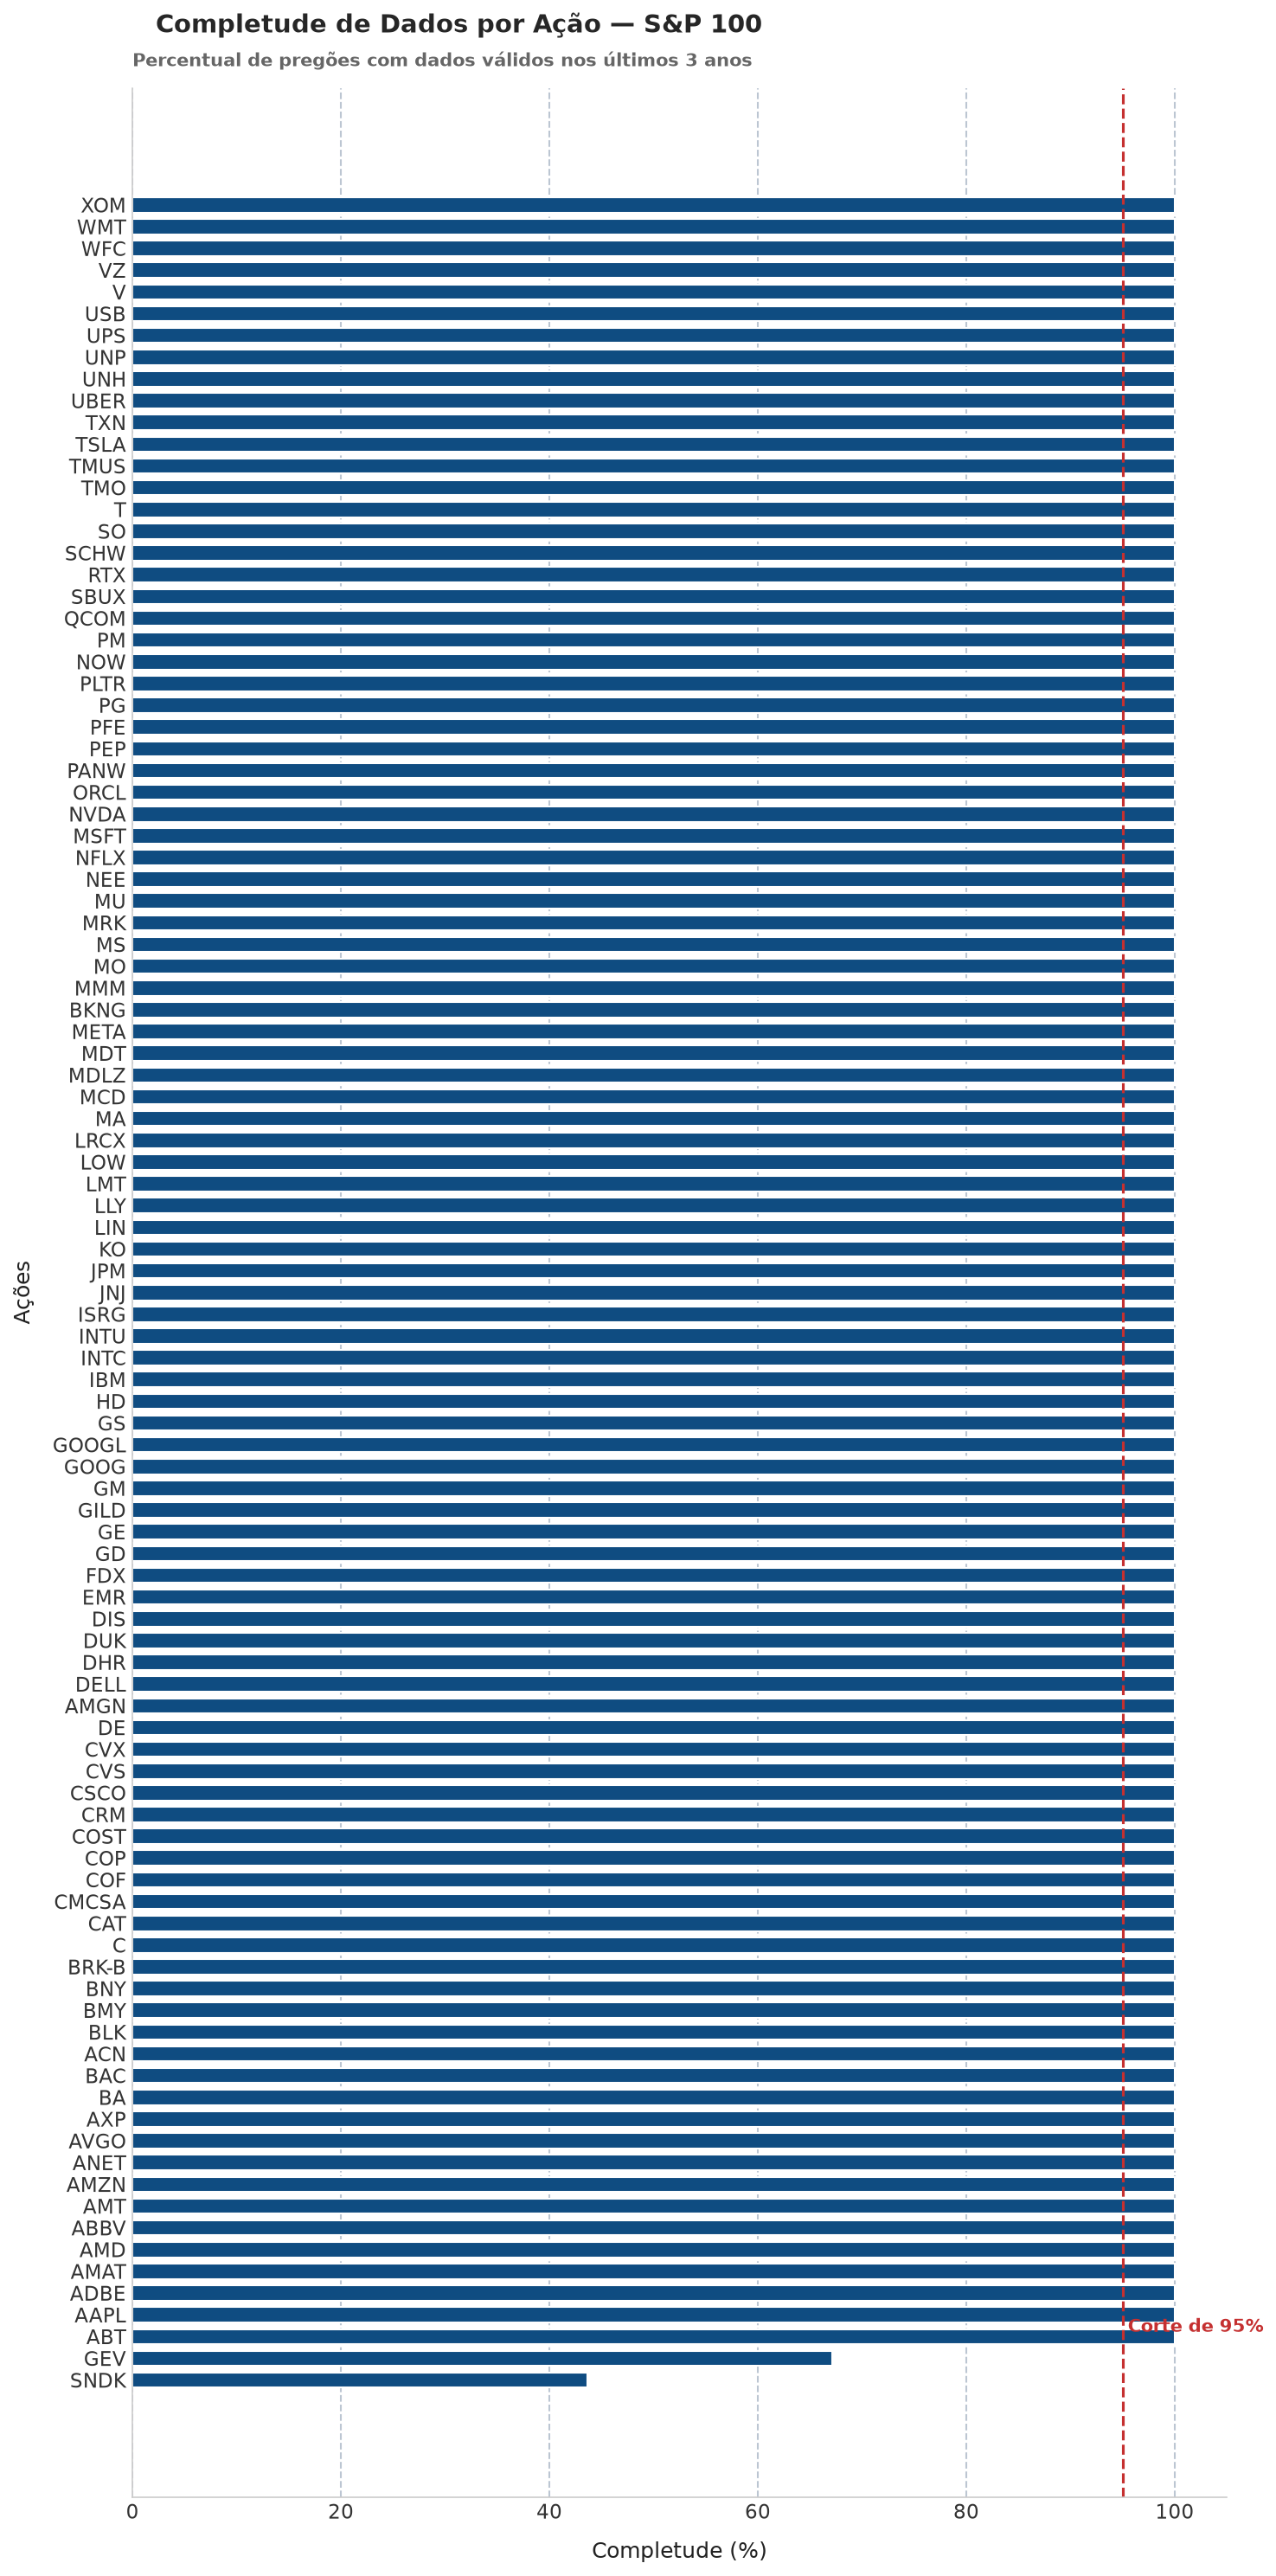

=== DADOS FALTANTES,IBOVESPA ===
Total de ações: 76
Ações sem nenhum dado faltante: 75
Ações com algum dado faltante: 1

Ações com até 5% de dados faltantes:
Series([], dtype: float64)

Ações com mais de 5% de dados faltantes:
Ticker
NATU3.SA    65.96
dtype: float64


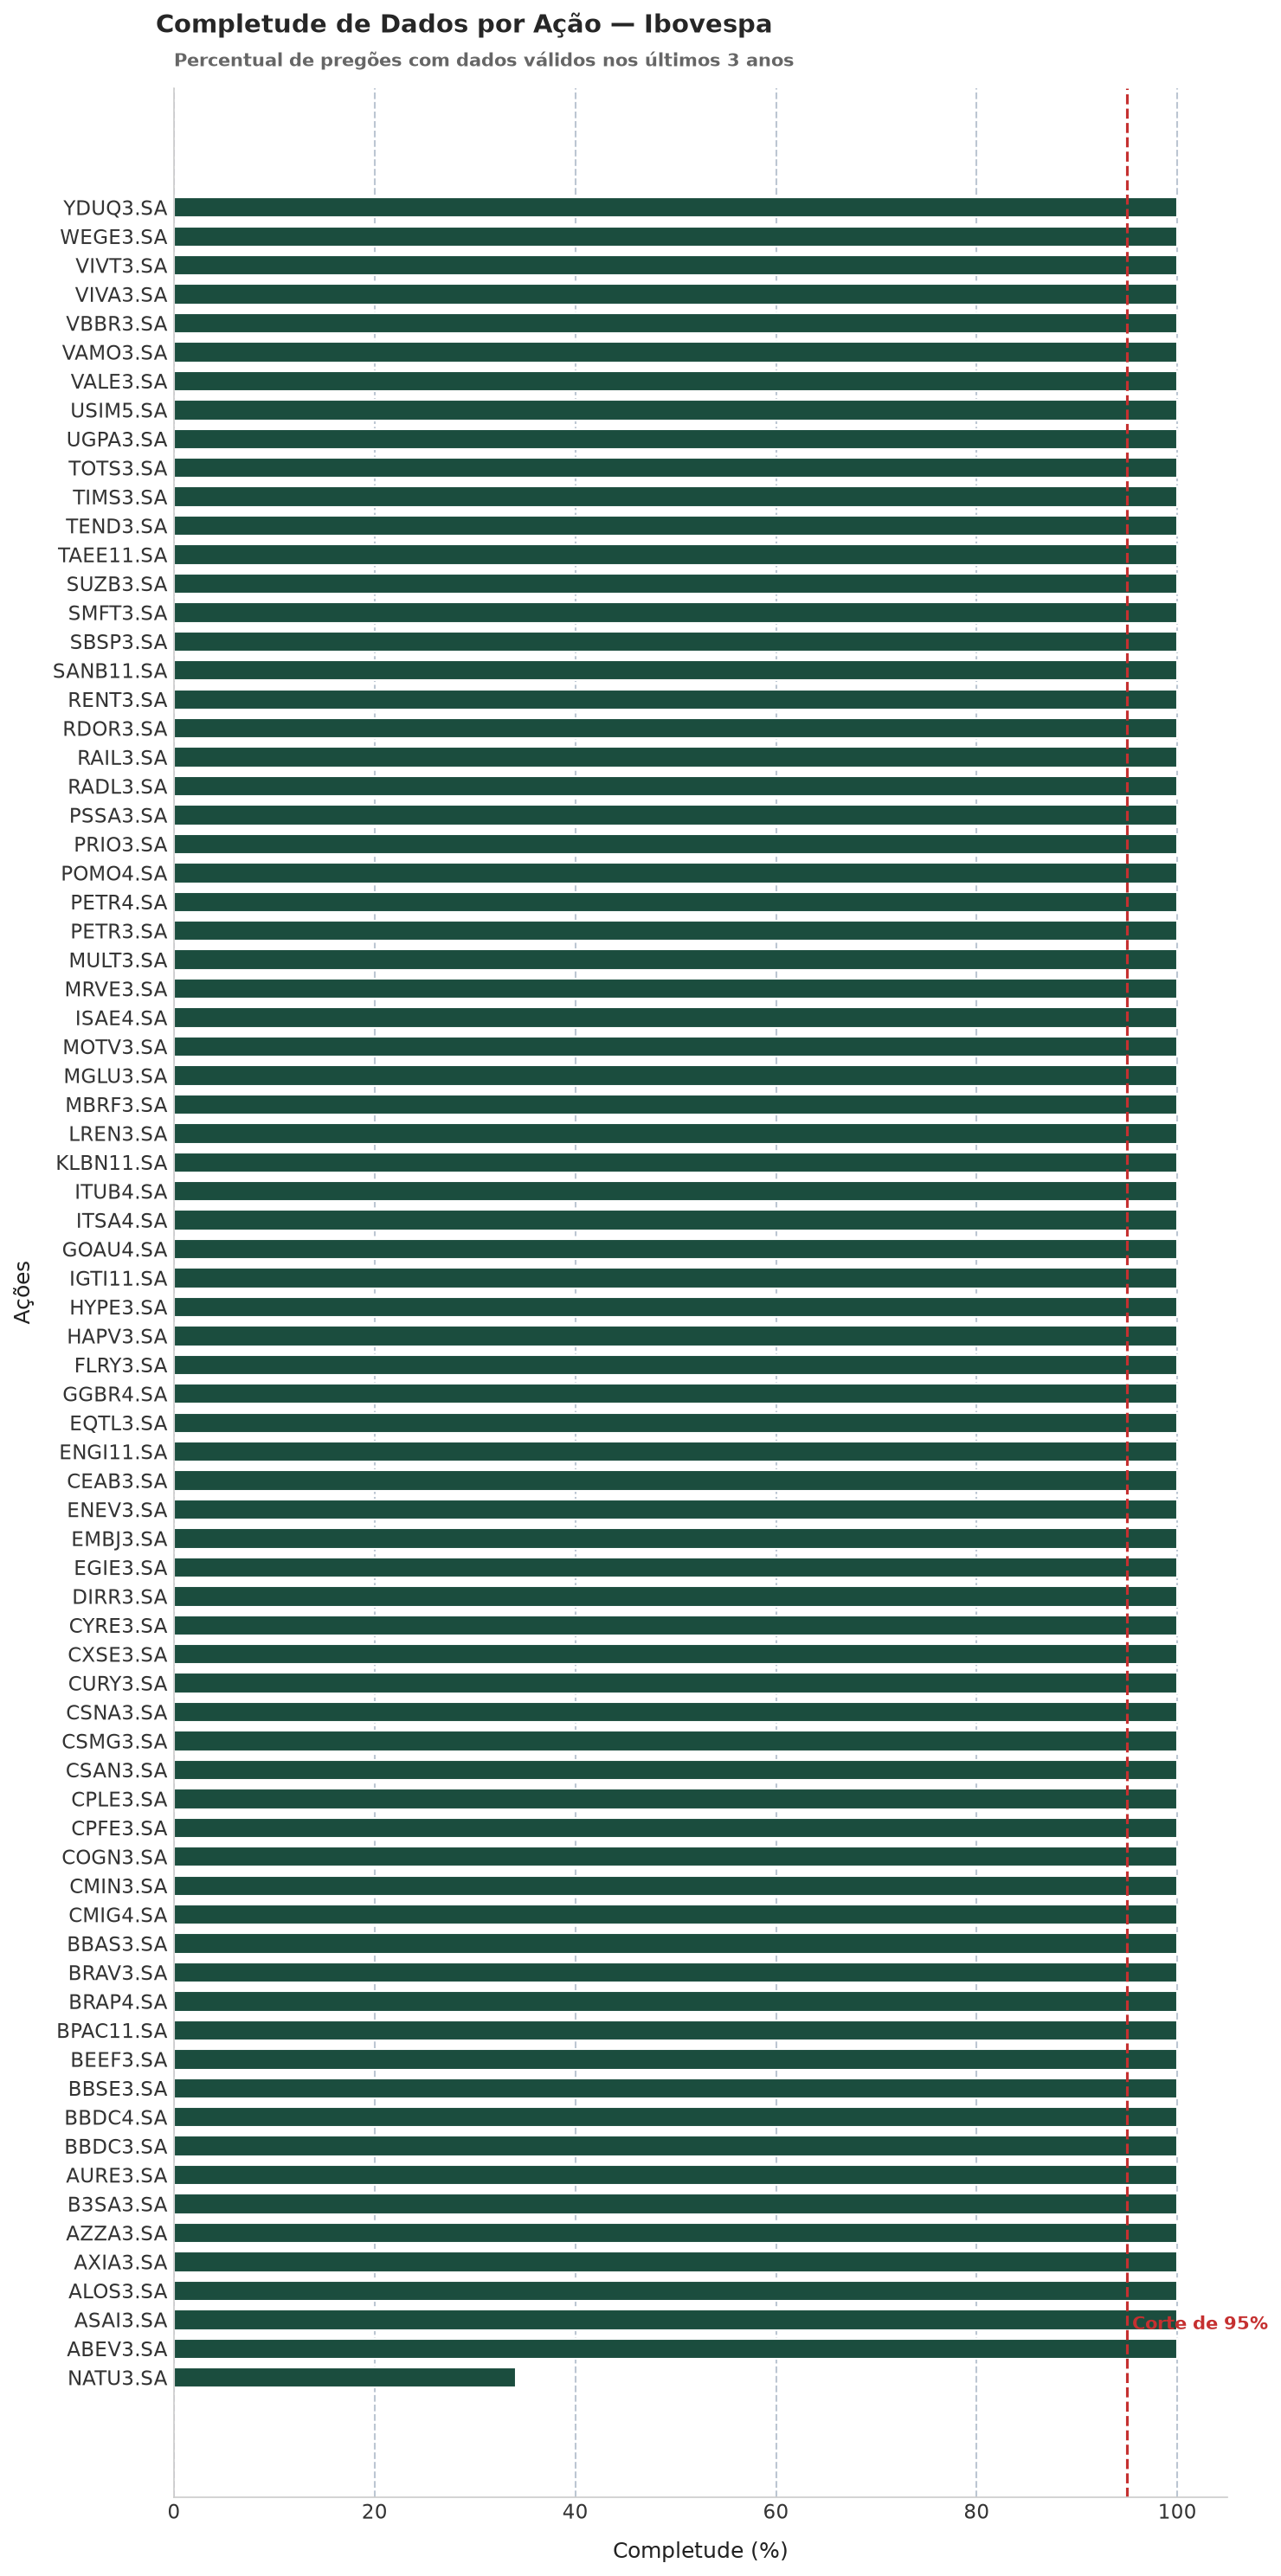

In [42]:
# ══════════════════════════════════════════════════════
# DIAGNÓSTICO DE DADOS FALTANTES, S&P100
# ══════════════════════════════════════════════════════

# Contagem e percentual de nulos por ação
nulos_sp = dados_sp100.isnull().sum()
pct_nulos = (nulos_sp / len(dados_sp100) * 100).round(2)
print('=== DADOS FALTANTES,S&P100 ===')
print(f'Total de ações: {dados_sp100.shape[1]}')
print(f'Ações sem nenhum dado faltante: {(pct_nulos == 0).sum()}')
print(f'Ações com algum dado faltante: {(pct_nulos > 0).sum()}')
print("\nAções com até 5% de dados faltantes:")
print(pct_nulos[pct_nulos.between(0, 5, inclusive='right')])
print(f'\nAções com mais de 5% de dados faltantes:')
print(pct_nulos[pct_nulos > 5].sort_values(ascending=False))

# Visualização,mapa de calor de dados faltantes
completude = (dados_sp100.notnull().mean() * 100).sort_values(ascending=True) # Calcula a completude em porcentagem para cada ação
set_nyt_style()
fig, ax = plt.subplots(figsize=(10, 20), dpi=150)
ax.barh(completude.index, completude.values, color=CORES['sp100'], height=0.7) #Plota as barras horizontais
ax.axvline(x=95, color=CORES['alerta'], linestyle='--', linewidth=1.5, label='Limite de 95%') #Adiciona a linha pontilhada em 95% (Destaque)
# Configuração de eixos e limites
ax.set_xlim(0, 105) # Limite até 105% para dar margem visual no topo
ax.set_xlabel("Completude (%)", fontsize=12, labelpad=10)
ax.set_ylabel("Ações", fontsize=12, labelpad=10)
#Definindo o Título e Subtítulo no estilo NYT
plt.suptitle('Completude de Dados por Ação — S&P 100', x=0.125, y=0.99, fontweight='bold', fontsize=14, ha='left')
ax.set_title('Percentual de pregões com dados válidos nos últimos 3 anos', fontsize=10, color='#666666', pad=12, loc='left')
#Inserir um rótulo de texto diretamente na linha de 95% em vez de usar legenda comum
ax.text(95.5, len(completude)*0.02, 'Corte de 95%', color=CORES['alerta'], fontweight='bold', fontsize=10, va='bottom')
ax.grid(axis='x', color=CORES['neutro'], linestyle='--', alpha=0.7) #suave apenas no eixo X para facilitar a leitura da porcentagem
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig('missing_sp100.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════
# DIAGNÓSTICO DE DADOS FALTANTES, IBOVESPA
# ══════════════════════════════════════════════════════

# Contagem e percentual de nulos por ação
nulos_sp = dados_ibov.isnull().sum()
pct_nulos = (nulos_sp / len(dados_ibov) * 100).round(2)
print('=== DADOS FALTANTES,IBOVESPA ===')
print(f'Total de ações: {dados_ibov.shape[1]}')
print(f'Ações sem nenhum dado faltante: {(pct_nulos == 0).sum()}')
print(f'Ações com algum dado faltante: {(pct_nulos > 0).sum()}')
print("\nAções com até 5% de dados faltantes:")
print(pct_nulos[pct_nulos.between(0, 5, inclusive='right')])
print(f'\nAções com mais de 5% de dados faltantes:')
print(pct_nulos[pct_nulos > 5].sort_values(ascending=False))

# Visualização,mapa de calor de dados faltantes

completude = (dados_ibov.notnull().mean() * 100).sort_values(ascending=True) # Calcula a completude em porcentagem para cada ação
set_nyt_style()
fig, ax = plt.subplots(figsize=(10, 20), dpi=150)
ax.barh(completude.index, completude.values, color=CORES['ibov'], height=0.7) #Plota as barras horizontais
ax.axvline(x=95, color=CORES['alerta'], linestyle='--', linewidth=1.5, label='Limite de 95%') #Adiciona a linha pontilhada em 95% (Destaque)
# Configuração de eixos e limites
ax.set_xlim(0, 105) # Limite até 105% para dar margem visual no topo
ax.set_xlabel("Completude (%)", fontsize=12, labelpad=10)
ax.set_ylabel("Ações", fontsize=12, labelpad=10)
#Definindo o Título e Subtítulo no estilo NYT
plt.suptitle('Completude de Dados por Ação — Ibovespa', x=0.125, y=0.99, fontweight='bold', fontsize=14, ha='left')
ax.set_title('Percentual de pregões com dados válidos nos últimos 3 anos', fontsize=10, color='#666666', pad=12, loc='left')
#Inserir um rótulo de texto diretamente na linha de 95% em vez de usar legenda comum
ax.text(95.5, len(completude)*0.02, 'Corte de 95%', color=CORES['alerta'], fontweight='bold', fontsize=10, va='bottom')
ax.grid(axis='x', color=CORES['neutro'], linestyle='--', alpha=0.7) #suave apenas no eixo X para facilitar a leitura da porcentagem
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig('missing_ibov.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ==============================================================================
# ALINHAMENTO DE DATAS E CONVERSÃO SEGURA PARA SERIES
# ==============================================================================
datas_comuns = ret_idx_sp.index.intersection(ret_idx_ib.index)

# Se o seu DataFrame tiver apenas 1 coluna do índice (^OEX e ^BVSP), extraímos como Series:
# (Caso ret_idx_sp tenha 99 colunas, selecione a coluna do benchmark: ret_idx_sp['^OEX'])
s_sp = ret_idx_sp.loc[datas_comuns].squeeze()
s_ib = ret_idx_ib.loc[datas_comuns].squeeze()

# Se por acaso ainda for DataFrame de 1 coluna, forçamos a virar Series:
if isinstance(s_sp, pd.DataFrame):
    s_sp = s_sp.iloc[:, 0]
if isinstance(s_ib, pd.DataFrame):
    s_ib = s_ib.iloc[:, 0]

print(f"✅ Total de pregões comuns analisados: {len(datas_comuns)} dias úteis")
print(f"Período: {datas_comuns[0].strftime('%d/%m/%Y')} a {datas_comuns[-1].strftime('%d/%m/%Y')}\n")

# ==============================================================================
# CÁLCULO DOS RETORNOS ACUMULADOS (BASE 100)
# ==============================================================================
# Para retornos logarítmicos, o acumulado exato é np.exp(cum_sum):
sp_acum = np.exp(s_sp.cumsum()) * 100
ib_acum = np.exp(s_ib.cumsum()) * 100

# ==============================================================================
# TABELA RESUMO COMPARATIVA (COM CONVERSÃO EXPLÍCITA EM FLOAT)
# ==============================================================================
tabela_resumo = pd.DataFrame({
    'S&P 100 (^OEX)': [
        f"{float(s_sp.mean() * 252 * 100):.2f}%",                  # Retorno Anualizado
        f"{float(s_sp.std() * np.sqrt(252) * 100):.2f}%",           # Volatilidade Anualizada
        f"{float(s_sp.mean() / s_sp.std() * np.sqrt(252)):.3f}",    # Sharpe Anualizado
        f"{float(sp_acum.iloc[-1] - 100):.2f}%",                    # Retorno Acumulado Total
        f"{float(s_sp.min() * 100):.2f}%",                          # Pior Dia
        f"{float(s_sp.max() * 100):.2f}%"                           # Melhor Dia
    ],
    'IBOVESPA (^BVSP)': [
        f"{float(s_ib.mean() * 252 * 100):.2f}%",
        f"{float(s_ib.std() * np.sqrt(252) * 100):.2f}%",
        f"{float(s_ib.mean() / s_ib.std() * np.sqrt(252)):.3f}",
        f"{float(ib_acum.iloc[-1] - 100):.2f}%",
        f"{float(s_ib.min() * 100):.2f}%",
        f"{float(s_ib.max() * 100):.2f}%"
    ]
}, index=[
    'Retorno Anualizado', 
    'Volatilidade Anualizada', 
    'Sharpe Anualizado', 
    'Retorno Acumulado Total', 
    'Pior Dia (Retorno Mín.)', 
    'Melhor Dia (Retorno Máx.)'
])

print("=== COMPARATIVO S&P 100 vs. IBOVESPA ===")
print(tabela_resumo.to_string())

✅ Total de pregões comuns analisados: 911 dias úteis
Período: 04/01/2023 a 01/10/2026

=== COMPARATIVO S&P 100 vs. IBOVESPA ===
                          S&P 100 (^OEX) IBOVESPA (^BVSP)
Retorno Anualizado                25.18%           16.22%
Volatilidade Anualizada           15.59%           15.84%
Sharpe Anualizado                  1.615            1.024
Retorno Acumulado Total          148.54%           79.76%
Pior Dia (Retorno Mín.)           -6.13%           -4.40%
Melhor Dia (Retorno Máx.)          9.71%            4.20%


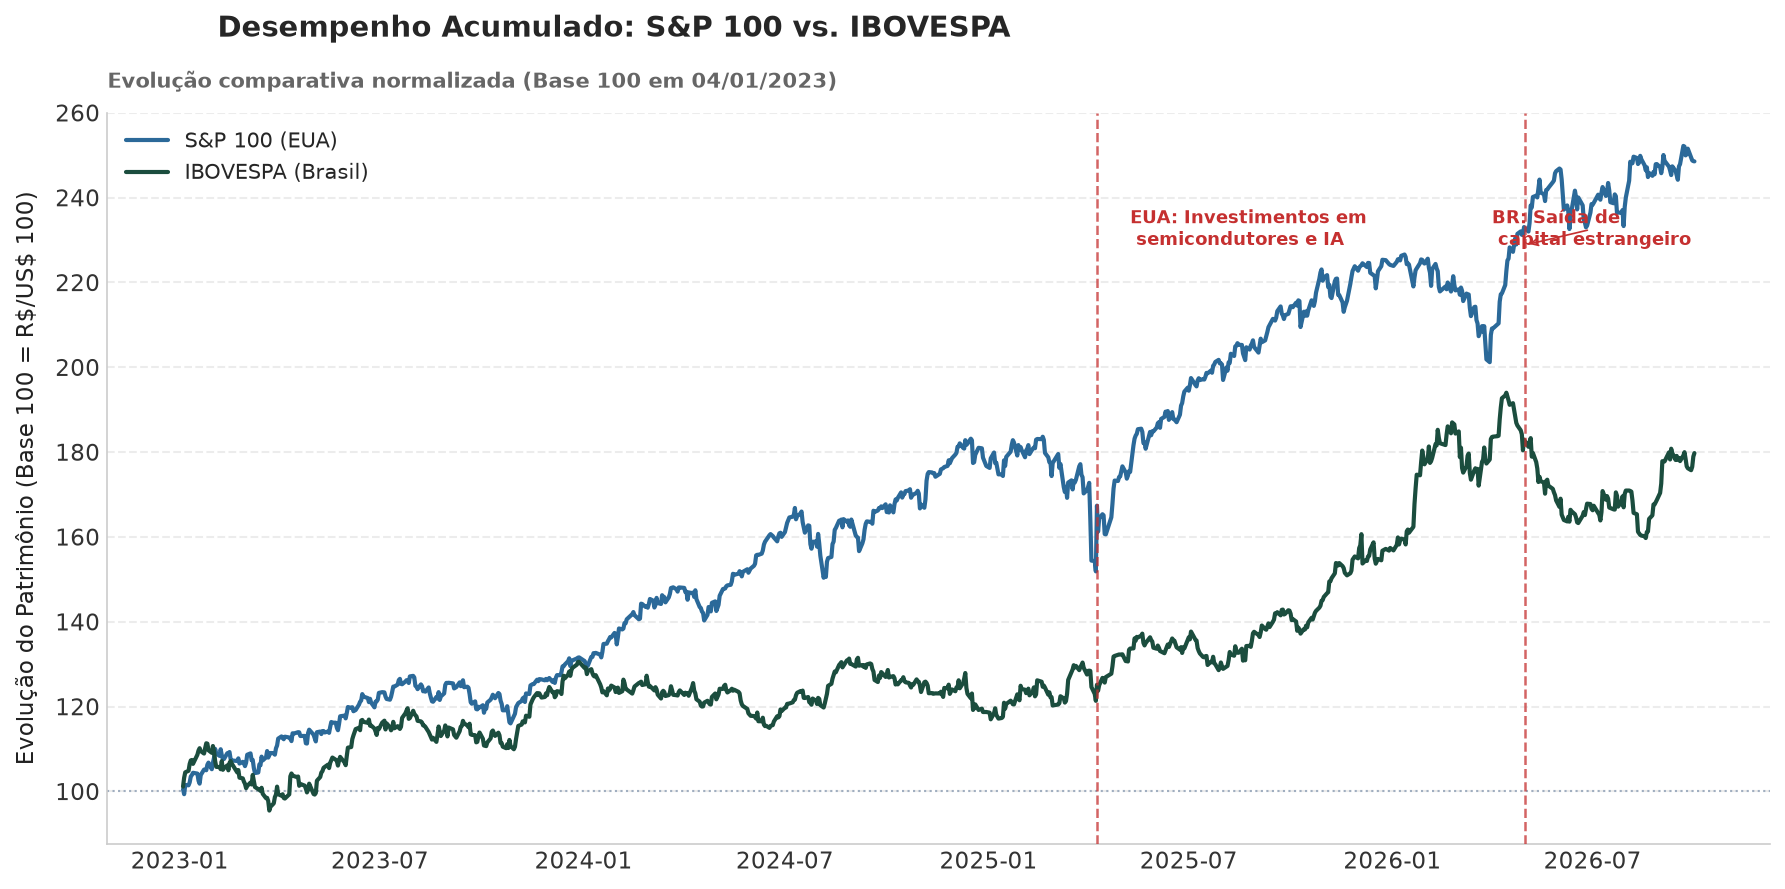

In [ ]:
# ==============================================================================
# GRÁFICO COMPARATIVO DE PERFORMANCE ACUMULADA DOS INDICES
# ==============================================================================
# Garante que as configurações visuais do NYT estão ativas
set_nyt_style()

# Criando figura com a interface Orientada a Objetos
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

# Linha de referência no ponto de partida (Base 100)
ax.axhline(y=100, color='#A0AEC0', linestyle=':', linewidth=1, zorder=1)

# Plot dos índices usando a paleta oficial padronizada do projeto
ax.plot(sp_acum.index, sp_acum, color='#2B6999', linewidth=2, label='S&P 100 (EUA)', zorder=2)
ax.plot(ib_acum.index, ib_acum, color='#1B4D3E', linewidth=2, label='IBOVESPA (Brasil)', zorder=2)

# Grid sutil apenas no eixo Y para não poluir
ax.grid(axis='y', color='#E5E5E5', linestyle='--', alpha=0.7)
ax.grid(axis='x', visible=False)

# Hierarquia do Título (Estilo Manchete Editorial NYT)
plt.suptitle('Desempenho Acumulado: S&P 100 vs. IBOVESPA', x=0.125, y=0.98, fontweight='bold', fontsize=14, ha='left')
ax.set_title(
    f"Evolução comparativa normalizada (Base 100 em {datas_comuns[0].strftime('%d/%m/%Y')})", 
    fontsize=10, color='#666666', pad=12, loc='left'
)

# 6. Marcação de Eventos Históricos de Mercado
data_baixa_B3 = pd.to_datetime('2026-05-01')
data_alta_usa = pd.to_datetime('2025-04-09')

# Linha e anotação: Mínimo no Brasil (Maio 2026)
ax.axvline(data_baixa_B3, color='#C53030', linestyle='--', linewidth=1.2, alpha=0.75, zorder=3)
ax.annotate('BR: Saída de \n capital estrangeiro', xy=(data_baixa_B3, ax.get_ylim()[1] * 0.88), 
            xytext=(data_baixa_B3 - pd.Timedelta(days=30), ax.get_ylim()[1] * 0.88),
            fontsize=8.5, color='#C53030', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C53030', lw=0.8))

# Linha e anotação: Início dalta pontual histórica EUA (Mai 2025)
ax.axvline(data_alta_usa, color='#C53030', linestyle='--', linewidth=1.2, alpha=0.75, zorder=3)
ax.annotate('EUA: Investimentos em \n semicondutores e IA', xy=(data_alta_usa, ax.get_ylim()[1] * 0.88), 
            xytext=(data_alta_usa + pd.Timedelta(days=30), ax.get_ylim()[1] * 0.88),
            fontsize=8.5, color='#C53030', fontweight='bold')

# Ajuste dos eixos
ax.set_ylabel('Evolução do Patrimônio (Base 100 = R\\$/US\\$ 100)', fontsize=11, labelpad=8)
ax.set_xlabel('', fontsize=11) # Em séries de tempo, dispensamos a legenda "Data"

# Legenda limpa (sem moldura)
ax.legend(frameon=False, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('comparativo_acumulado_indices.png', dpi=300, bbox_inches='tight')
plt.show()

IBOVESPA
Total de ações originais: 76
Total de ações mantidas:  75

S&P100
Total de ações originais: 101
Total de ações mantidas:  99

Retornos finais,IBOV: (936, 75)
Retornos finais,S&P100: (939, 99)


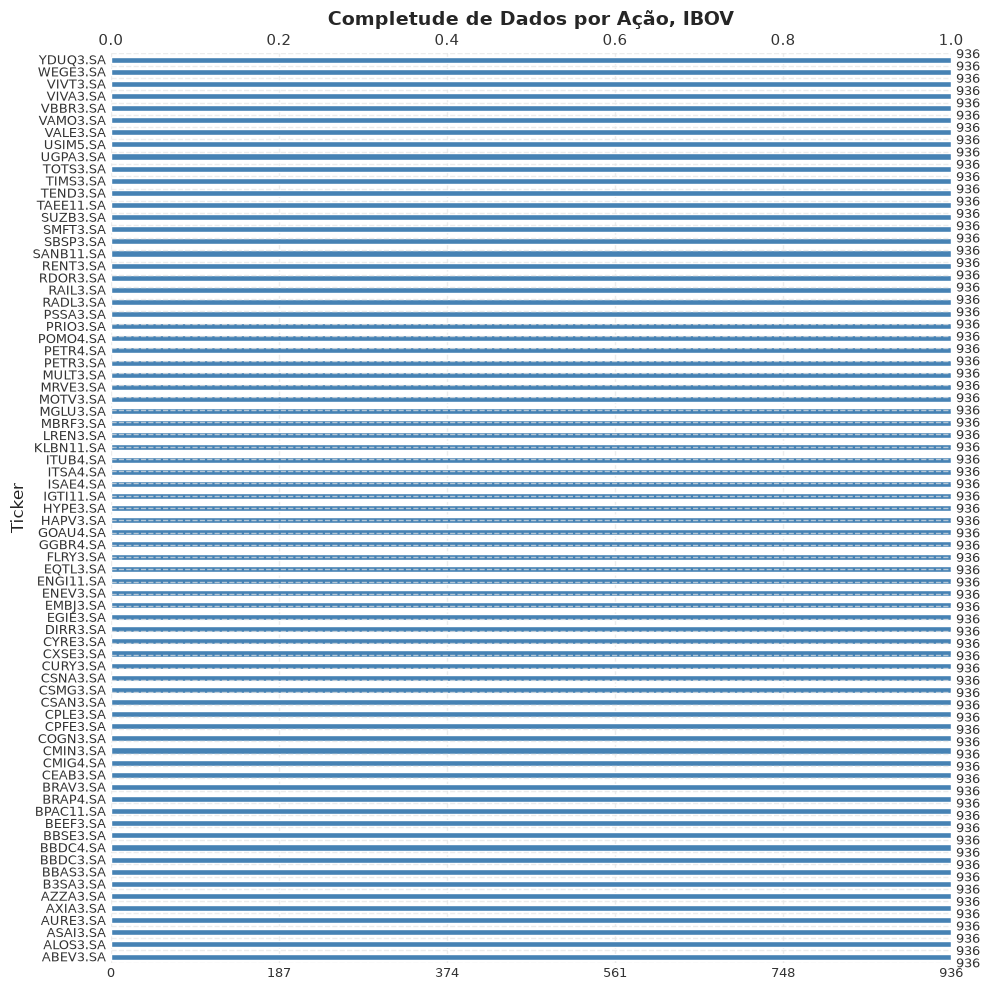

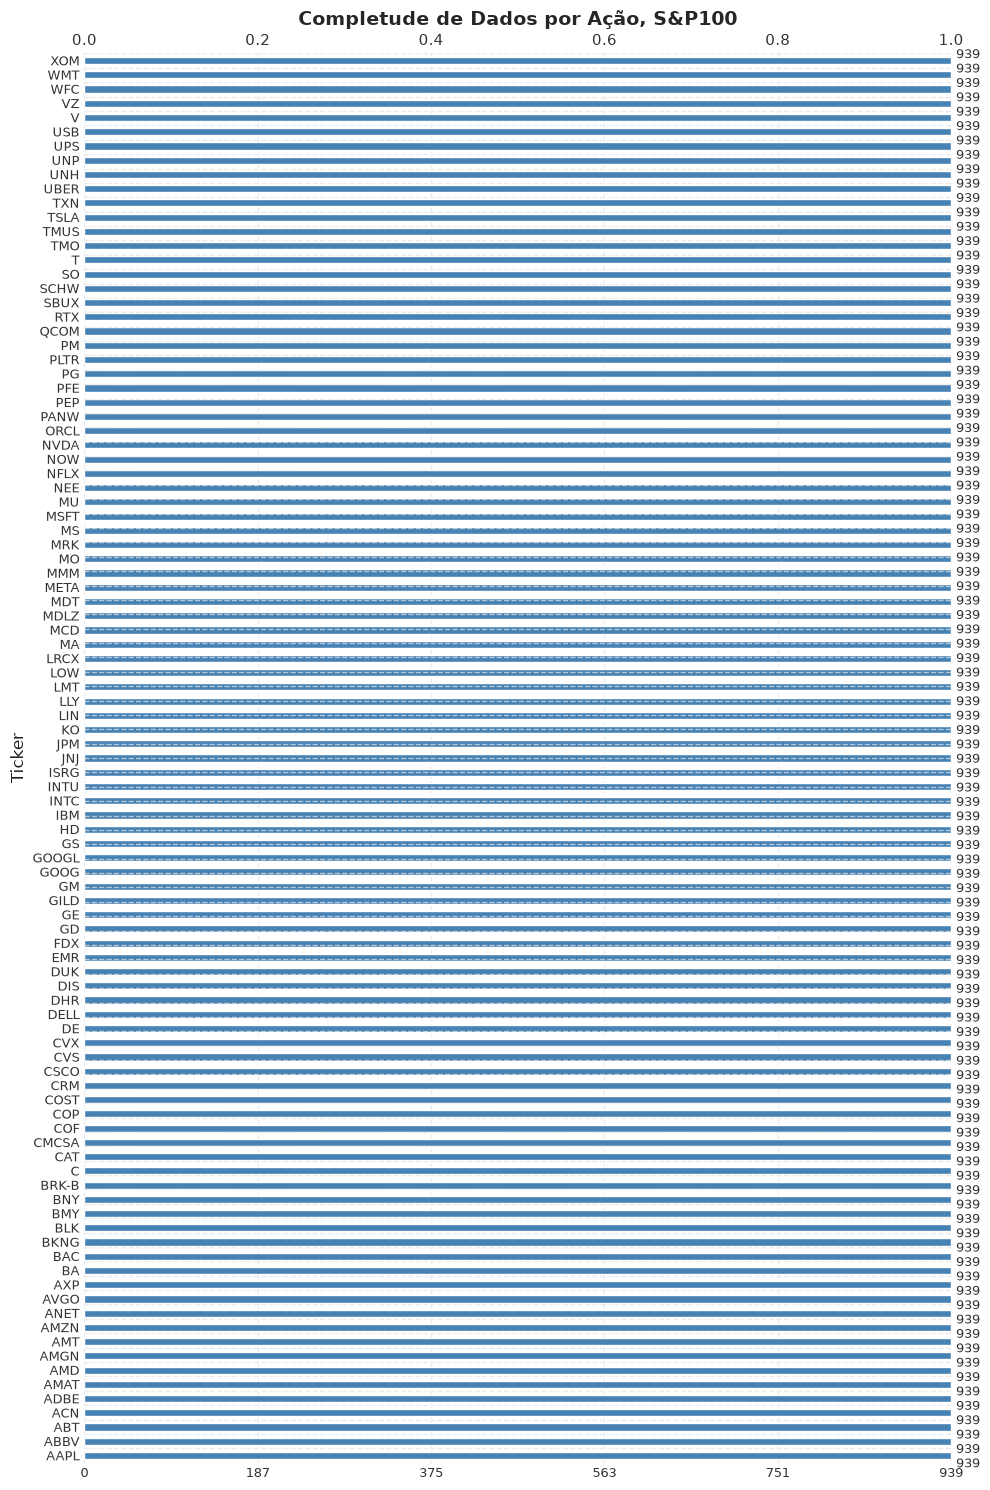

In [46]:
# ══════════════════════════════════════════════════════
# TRATAMENTO DE DADOS FALTANTES
# ══════════════════════════════════════════════════════

# 1. Definir o limite máximo tolerado de NaNs (ex: 5%)
limite_remocao = 5.0

# 2. Calcular a porcentagem de nulos de CADA AÇÃO (por coluna)
pct_nulos_sp100 = dados_sp100.isna().mean() * 100
pct_nulos_ibov = dados_ibov.isna().mean() * 100

# 3. Filtrar as ações que estão DENTRO do limite e extrair os nomes
acoes_validas_sp100 = pct_nulos_sp100[pct_nulos_sp100 <= limite_remocao].index
acoes_validas_ibov = pct_nulos_ibov[pct_nulos_ibov <= limite_remocao].index

#Criando o novo DataFrame filtrado contendo apenas as ações válidas
dados_sp100_clean = dados_sp100[acoes_validas_sp100]
dados_ibov_clean = dados_ibov[acoes_validas_ibov]

# 4 Preencher dados faltantes (<5%) restantes com forward fill
dados_sp100_clean = dados_sp100_clean.ffill() # ffill preenche com o último valor disponível
dados_ibov_clean = dados_ibov_clean.ffill()

# 5. Criar o novo DataFrame filtrado contendo apenas as ações válidas
dados_sp100_clean = dados_sp100[acoes_validas_sp100]
dados_ibov_clean = dados_ibov[acoes_validas_ibov]
print ("IBOVESPA")
print(f"Total de ações originais: {dados_ibov.shape[1]}")
print(f"Total de ações mantidas:  {len(acoes_validas_ibov)}")

print ("\nS&P100")
print(f"Total de ações originais: {dados_sp100.shape[1]}")
print(f"Total de ações mantidas:  {len(acoes_validas_sp100)}")

# 6. Verificar se ainda há nulos (linhas iniciais podem ter NaN)
dados_sp100_clean = dados_sp100_clean.dropna(how='all')
dados_ibov_clean = dados_ibov_clean.dropna(how='all')

# Recalcular retornos com dados limpos
ret_sp100_clean = np.log(dados_sp100_clean / dados_sp100_clean.shift(1)).dropna()
ret_ibov_clean = np.log(dados_ibov_clean / dados_ibov_clean.shift(1)).dropna()
print(f'\nRetornos finais,IBOV: {ret_ibov_clean.shape}')
print(f'Retornos finais,S&P100: {ret_sp100_clean.shape}')

# Visualização, mapa de calor de dados completos após limpeza
fig, ax = plt.subplots(figsize=(10, 10))
msno.bar(ret_ibov_clean, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação, IBOV', fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 15))
msno.bar(ret_sp100_clean, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Completude de Dados por Ação, S&P100', fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
# ══════════════════════════════════════════════════════
#Identificação de Outliers nos Retornos
# ══════════════════════════════════════════════════════

# Detectar retornos extremos por ação
limite_outlier = 0.15 # ±15% em um dia,ajuste conforme necessário
outliers_sp = (ret_sp100_clean.abs() > limite_outlier).sum()
print('Ações com retornos diários > 15% (S&P100):')
print(outliers_sp[outliers_sp > 0].sort_values(ascending=False).head(15))

outliers_ibov = (ret_ibov_clean.abs() > limite_outlier).sum()
print('\nAções com retornos diários > 15% (IBOV):')
print(outliers_ibov[outliers_ibov > 0].sort_values(ascending=False).head(15))

# ══════════════════════════════════════════════════════
#Aqui Investiga uma ação específica suspeita
# ══════════════════════════════════════════════════════
acao_suspeita = 'TSLA' # Substituir por qualquer ação do S&P100 ou IBOVESPA que você queira investigar
if acao_suspeita in ret_sp100_clean.columns:
    retornos_acao = ret_sp100_clean[acao_suspeita]
    dias_extremos = retornos_acao[retornos_acao.abs() > limite_outlier]
    print(f'\nDias com retorno extremo,{acao_suspeita}:')
    formato = len(dias_extremos)
    print(dias_extremos.sort_values(key=abs, ascending=False))
    print(f'Quantidade de dias extremos: {formato}')

Ações com retornos diários > 15% (S&P100):
Ticker
PLTR    9
DELL    7
MU      5
INTC    5
TSLA    5
NVDA    4
ANET    4
AMD     4
AVGO    3
UNH     3
CVS     2
CRM     2
META    2
SBUX    2
LRCX    2
dtype: int64

Ações com retornos diários > 15% (IBOV):
Ticker
HAPV3.SA    6
CEAB3.SA    5
MGLU3.SA    4
YDUQ3.SA    3
RADL3.SA    2
TEND3.SA    2
MBRF3.SA    2
BRAV3.SA    2
BEEF3.SA    1
BBDC4.SA    1
AZZA3.SA    1
AXIA3.SA    1
LREN3.SA    1
CYRE3.SA    1
CSAN3.SA    1
dtype: int64

Dias com retorno extremo,TSLA:
Date
2025-04-09    0.204491
2024-10-24    0.198187
2025-03-10   -0.167546
2026-07-23   -0.156931
2025-06-05   -0.153849
Name: TSLA, dtype: float64
Quantidade de dias extremos: 5


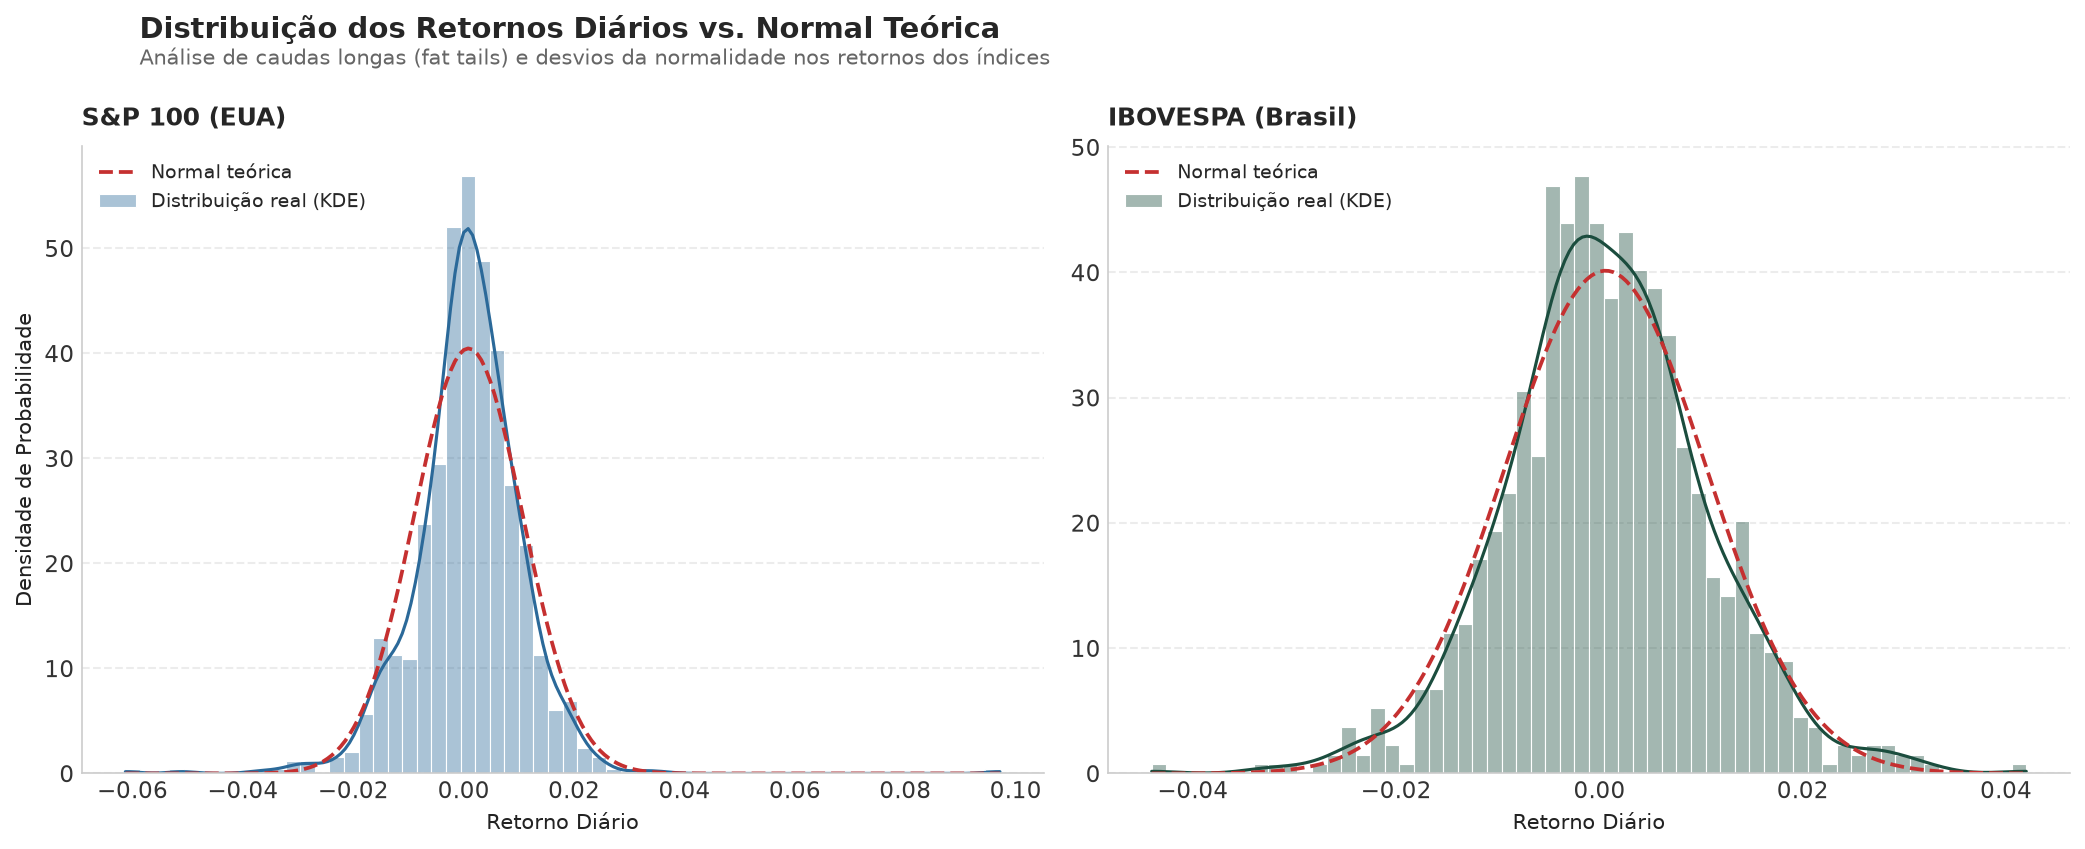

      ANÁLISE ESTATÍSTICA DE RISCO E DISTRIBUIÇÃO

--- ASSIMETRIA (SKEWNESS) ---
S&P 100:  0.35  (Normal = 0)
IBOVESPA: 0.03  (Normal = 0)

--- CURTOSE EM EXCESSO (KURTOSIS) ---
S&P 100:  12.15  (Normal = 0)
IBOVESPA: 1.10  (Normal = 0)

🔍 INTERPRETAÇÃO DOS RESULTADOS:
• Curtose > 0 (Fat Tails): Ambos os índices apresentam caudas gordas.
  Eventos extremos (choques e crises) ocorrem com frequência superior à prevista pela distribuição Normal.
• Assimetria > 0: Distribuição levemente inclinada
O valor de referência é 0,00, indicando uma curva perfeitamente simétrica onde ganhos e perdas têm distribuição espelhada


In [48]:
# ==============================================================================
# GRÁFICO DE DISTRIBUIÇÃO DE RETORNOS VS. CURVA NORMAL 
# ==============================================================================
set_nyt_style()

# Extração segura dos valores numéricos para cálculo estatístico
s_sp_vals = ret_idx_sp["^OEX"].dropna()
s_ib_vals = ret_idx_ib["^BVSP"].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=150)

# ------------------------------------------------------------------------------
# PAINEL 1: S&P 100 (EUA)
# ------------------------------------------------------------------------------
# Histograma e KDE real normalizados por densidade
sns.histplot(s_sp_vals, bins=60, stat="density", kde=True, 
             color='#2B6999', alpha=0.4, ax=ax1, label='Distribuição real (KDE)')

# Cálculo da Curva Normal Teórica
mu_sp, sigma_sp = s_sp_vals.mean(), s_sp_vals.std()
x_sp = np.linspace(s_sp_vals.min(), s_sp_vals.max(), 200)
pdf_sp = (1 / (sigma_sp * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_sp - mu_sp) / sigma_sp) ** 2)

ax1.plot(x_sp, pdf_sp, color=CORES['alerta'], linestyle='--', linewidth=1.8, label='Normal teórica')

# Ajustes estéticos - Painel 1
ax1.set_title('S&P 100 (EUA)', fontsize=12, fontweight='bold', loc='left', pad=10)
ax1.set_xlabel('Retorno Diário', fontsize=10)
ax1.set_ylabel('Densidade de Probabilidade', fontsize=10)
ax1.grid(axis='y', color='#E5E5E5', linestyle='--', alpha=0.7)
ax1.grid(axis='x', visible=False)
ax1.legend(frameon=False, loc='upper left', fontsize=9)

# ------------------------------------------------------------------------------
# PAINEL 2: IBOVESPA (Brasil)
# ------------------------------------------------------------------------------
# Histograma e KDE real normalizados por densidade
sns.histplot(s_ib_vals, bins=60, stat="density", kde=True, 
             color='#1B4D3E', alpha=0.4, ax=ax2, label='Distribuição real (KDE)')

# Cálculo da Curva Normal Teórica
mu_ib, sigma_ib = s_ib_vals.mean(), s_ib_vals.std()
x_ib = np.linspace(s_ib_vals.min(), s_ib_vals.max(), 200)
pdf_ib = (1 / (sigma_ib * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_ib - mu_ib) / sigma_ib) ** 2)

ax2.plot(x_ib, pdf_ib, color=CORES['alerta'], linestyle='--', linewidth=1.8, label='Normal teórica')

# Ajustes estéticos - Painel 2
ax2.set_title('IBOVESPA (Brasil)', fontsize=12, fontweight='bold', loc='left', pad=10)
ax2.set_xlabel('Retorno Diário', fontsize=10)
ax2.set_ylabel('', fontsize=10) # Remove rótulo duplicado no segundo painel
ax2.grid(axis='y', color='#E5E5E5', linestyle='--', alpha=0.7)
ax2.grid(axis='x', visible=False)
ax2.legend(frameon=False, loc='upper left', fontsize=9)

# ------------------------------------------------------------------------------
# TÍTULO GERAL E CONFIGURAÇÕES FINAIS
# ------------------------------------------------------------------------------
plt.suptitle('Distribuição dos Retornos Diários vs. Normal Teórica', x=0.07, y=1.02, fontweight='bold', fontsize=14, ha='left')
fig.text(0.07, 0.96, 'Análise de caudas longas (fat tails) e desvios da normalidade nos retornos dos índices', fontsize=10, color='#666666')

plt.tight_layout()
plt.savefig('distribuicao_retornos.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# CÁLCULO E EXIBIÇÃO DA ASSIMETRIA E CURTOSE
# ==============================================================================
skew_sp = s_sp_vals.skew()
skew_ib = s_ib_vals.skew()

kurt_sp = s_sp_vals.kurtosis()
kurt_ib = s_ib_vals.kurtosis()

print("=" * 55)
print("      ANÁLISE ESTATÍSTICA DE RISCO E DISTRIBUIÇÃO")
print("=" * 55)
print("\n--- ASSIMETRIA (SKEWNESS) ---")
print(f"S&P 100:  {skew_sp:.2f}  (Normal = 0)")
print(f"IBOVESPA: {skew_ib:.2f}  (Normal = 0)")

print("\n--- CURTOSE EM EXCESSO (KURTOSIS) ---")
print(f"S&P 100:  {kurt_sp:.2f}  (Normal = 0)")
print(f"IBOVESPA: {kurt_ib:.2f}  (Normal = 0)")
print("=" * 55)

# INTERPRETAÇÃO FINANCEIRA
print("\n🔍 INTERPRETAÇÃO DOS RESULTADOS:")
print("• Curtose > 0 (Fat Tails): Ambos os índices apresentam caudas gordas.")
print("  Eventos extremos (choques e crises) ocorrem com frequência superior à prevista pela distribuição Normal.")
print("• Assimetria > 0: Distribuição levemente inclinada")
print("O valor de referência é 0,00, indicando uma curva perfeitamente simétrica onde ganhos e perdas têm distribuição espelhada")

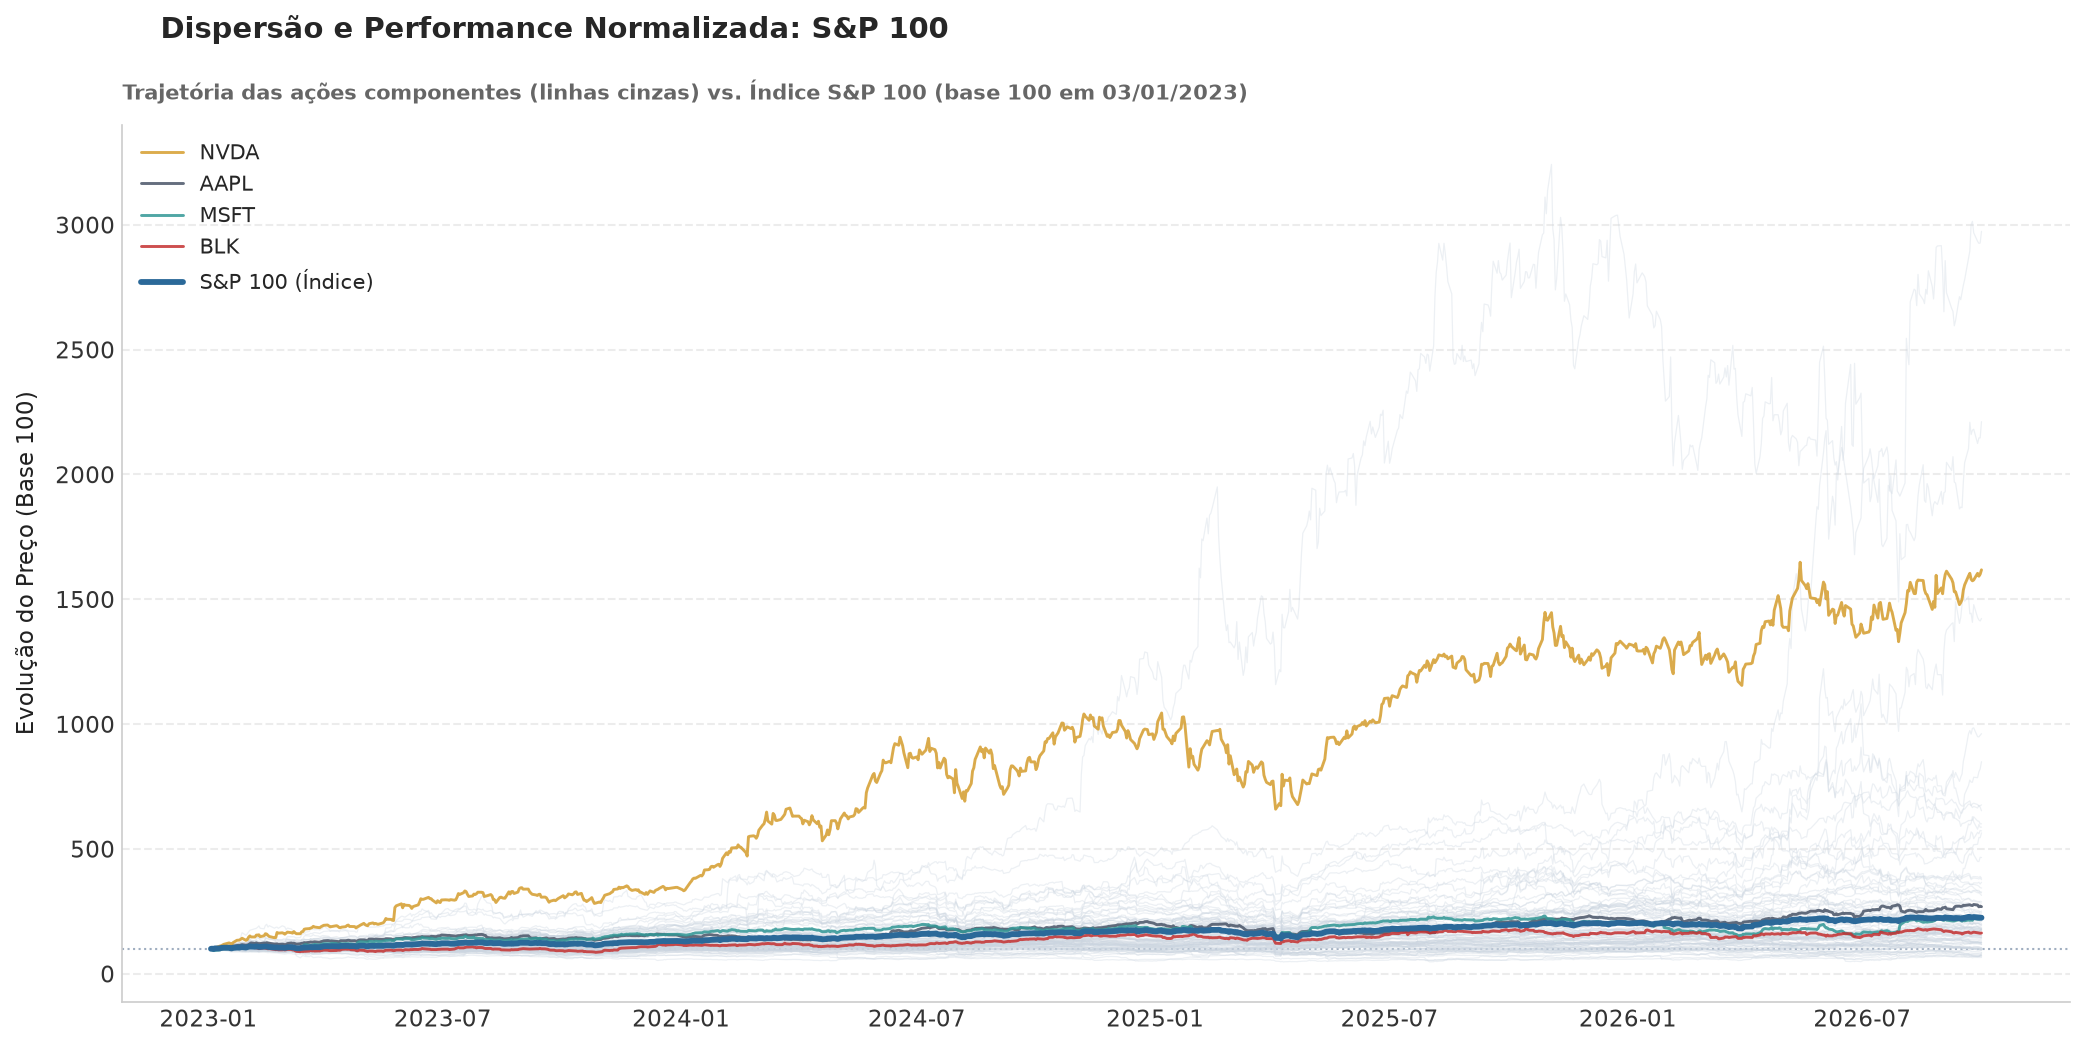

In [49]:
# ==============================================================================
# PERFORMANCE NORMALIZADA S&P 100
# ==============================================================================
set_nyt_style()

# 1. Cálculo da performance normalizada (Base 100 no início)
precos_norm_sp = (dados_sp100_clean / dados_sp100_clean.iloc[0] * 100)
indice_norm_sp = (indice_sp100 / indice_sp100.iloc[0] * 100)

fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

# 2. Linha de referência na Base 100
ax.axhline(y=100, color='#A0AEC0', linestyle=':', linewidth=1, zorder=1)

# 3. Ações individuais em cinza sutil ao fundo ("Feixe de luz")
for col in precos_norm_sp.columns:
    ax.plot(precos_norm_sp.index, precos_norm_sp[col], color='#CBD5E0', linewidth=0.6, alpha=0.35, zorder=2)

# 4. Destacar ações chave em tons sóbrios
destaques = {
    'NVDA': '#D69E2E',  # Dourado/Amber para alto crescimento
    'AAPL': '#4A5568',  # Cinza Escuro Slate
    'MSFT': '#319795',  # Teal/Azul-Verde
    'BLK':  CORES['alerta']  # Carmesim para contraste de queda/volatilidade
}

for acao, cor in destaques.items():
    if acao in precos_norm_sp.columns:
        ax.plot(precos_norm_sp.index, precos_norm_sp[acao], color=cor, linewidth=1.4, alpha=0.85, label=acao, zorder=3)

# 5. Índice S&P 100 em Destaque Principal (Azul Oficial do Projeto)
ax.plot(indice_norm_sp.index, indice_norm_sp, color='#2B6999', linewidth=2.8, label='S&P 100 (Índice)', zorder=4)


# 7. Ajustes Estéticos e Grid
ax.set_yscale('linear') # Mantenha 'log' se o pico da NVDA for excessivo e achatar as outras
ax.set_ylabel('Evolução do Preço (Base 100)', fontsize=11, labelpad=8)
ax.set_xlabel('', fontsize=11)
ax.grid(axis='y', color='#E5E5E5', linestyle='--', alpha=0.7)
ax.grid(axis='x', visible=False)

# Legenda Limpa
ax.legend(frameon=False, loc='upper left', fontsize=10)

# 8. Títulos no estilo NYT
plt.suptitle('Dispersão e Performance Normalizada: S&P 100', x=0.08, y=0.99, fontweight='bold', fontsize=14, ha='left')
ax.set_title(
    f"Trajetória das ações componentes (linhas cinzas) vs. Índice S&P 100 (base 100 em {precos_norm_sp.index[0].strftime('%d/%m/%Y')})", 
    fontsize=10, color='#666666', pad=12, loc='left'
)

plt.tight_layout()
plt.savefig('performance_normalizada_sp100.png', dpi=300, bbox_inches='tight')
plt.show()

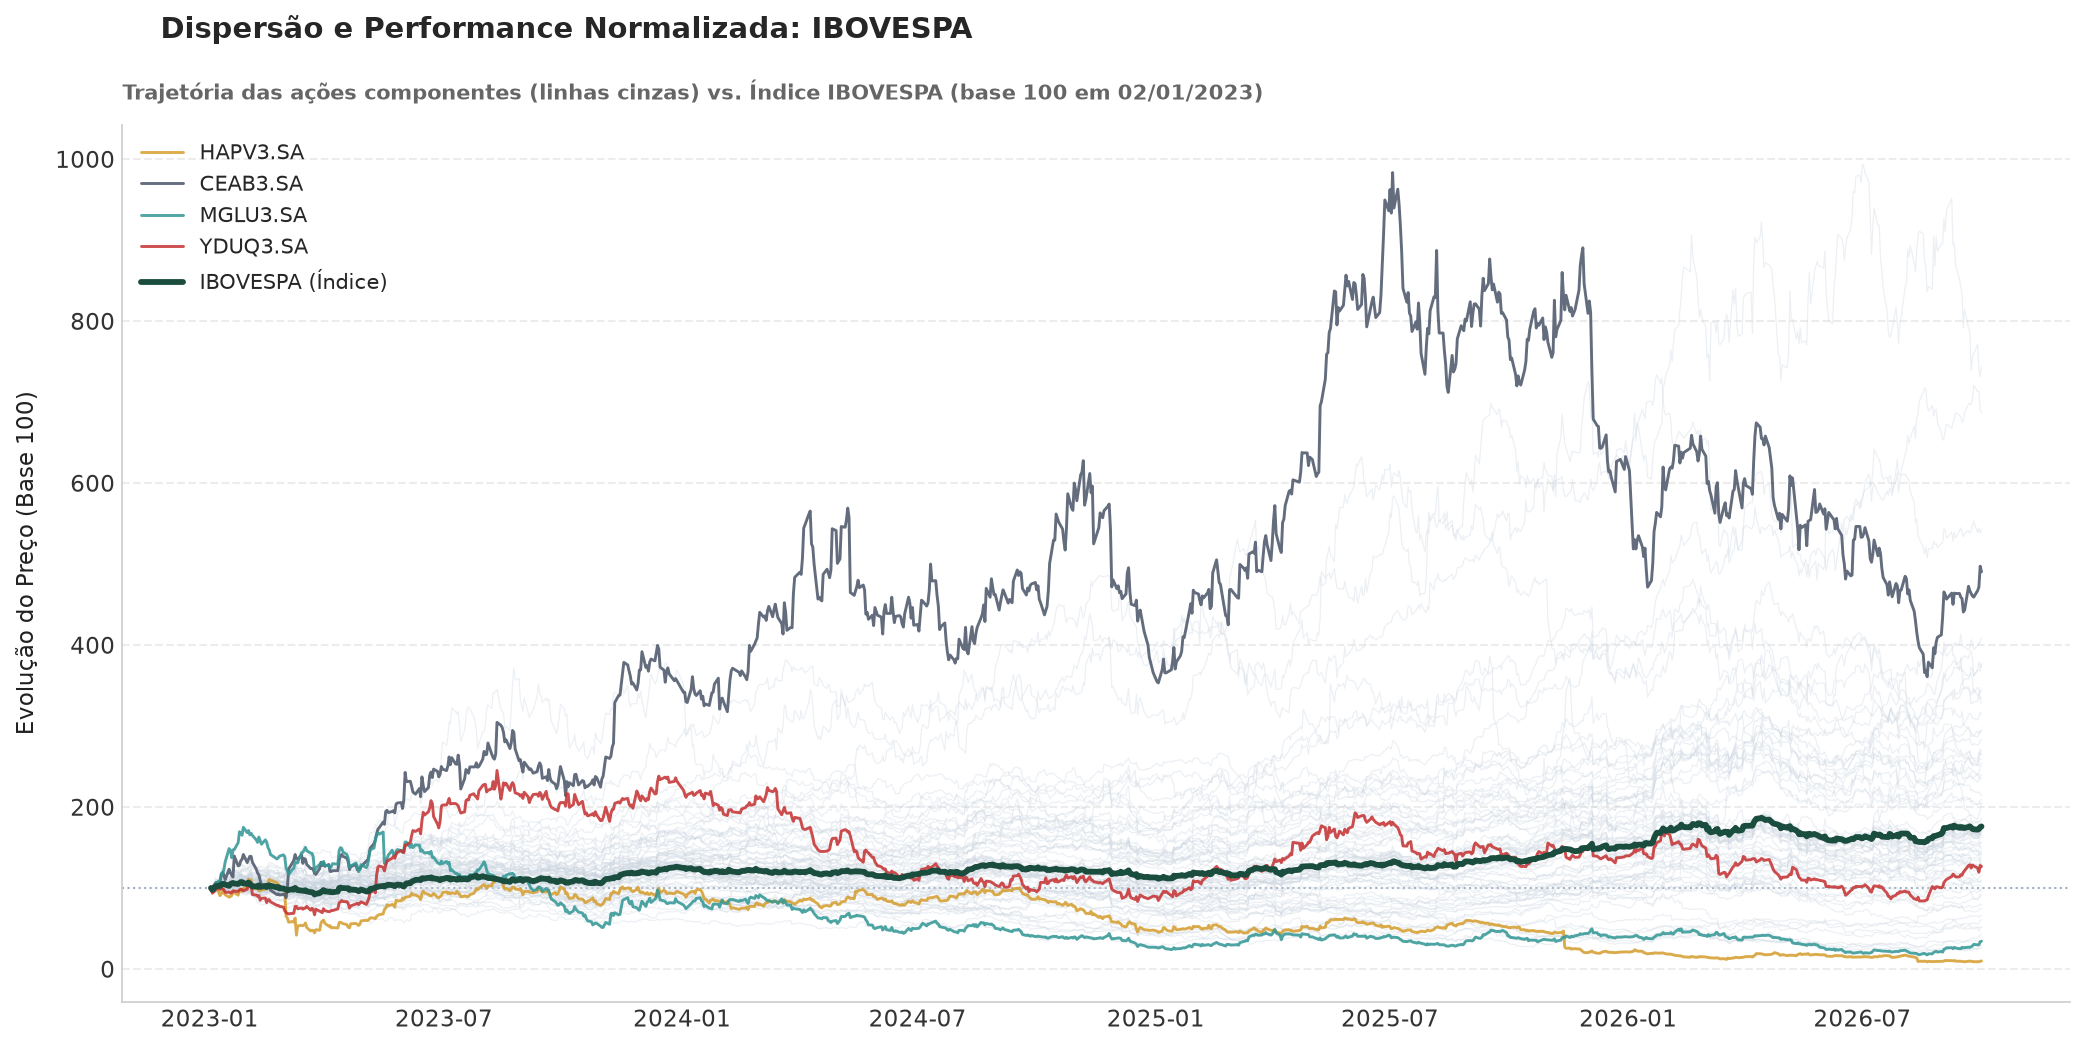

In [52]:
# ══════════════════════════════════════════════════════
# Performance Normalizada IBOVESPA
# ══════════════════════════════════════════════════════
set_nyt_style()

# 1. Cálculo da performance normalizada (Base 100 no início)
precos_norm_ib = (dados_ibov_clean / dados_ibov_clean.iloc[0] * 100)
indice_norm_ib = (indice_ibov / indice_ibov.iloc[0] * 100)

fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

# 2. Linha de referência na Base 100
ax.axhline(y=100, color='#A0AEC0', linestyle=':', linewidth=1, zorder=1)

# 3. Ações individuais em cinza sutil ao fundo ("Feixe de luz")
for col in precos_norm_ib.columns:
    ax.plot(precos_norm_ib.index, precos_norm_ib[col], color='#CBD5E0', linewidth=0.6, alpha=0.35, zorder=2)

# 4. Destacar ações chave em tons sóbrios
destaques = {
    'HAPV3.SA': '#D69E2E',  # Dourado/Amber para alto crescimento
    'CEAB3.SA': '#4A5568',  # Cinza Escuro Slate
    'MGLU3.SA': '#319795',  # Teal/Azul-Verde
    'YDUQ3.SA':  CORES['alerta']  # Carmesim para contraste de queda/volatilidade
}

for acao, cor in destaques.items():
    if acao in precos_norm_ib.columns:
        ax.plot(precos_norm_ib.index, precos_norm_ib[acao], color=cor, linewidth=1.4, alpha=0.85, label=acao, zorder=3)

# 5. Índice IBOVESPA em Destaque Principal (Verde Oficial do Projeto)
ax.plot(indice_norm_ib.index, indice_norm_ib, color=CORES['ibov'], linewidth=2.8, label='IBOVESPA (Índice)', zorder=4)


# 7. Ajustes Estéticos e Grid
ax.set_yscale('linear') # Mantenha 'log' se o pico da NVDA for excessivo e achatar as outras
ax.set_ylabel('Evolução do Preço (Base 100)', fontsize=11, labelpad=8)
ax.set_xlabel('', fontsize=11)
ax.grid(axis='y', color='#E5E5E5', linestyle='--', alpha=0.7)
ax.grid(axis='x', visible=False)

# Legenda Limpa
ax.legend(frameon=False, loc='upper left', fontsize=10)

# 8. Títulos no estilo NYT
plt.suptitle('Dispersão e Performance Normalizada: IBOVESPA', x=0.08, y=0.99, fontweight='bold', fontsize=14, ha='left')
ax.set_title(
    f"Trajetória das ações componentes (linhas cinzas) vs. Índice IBOVESPA (base 100 em {precos_norm_ib.index[0].strftime('%d/%m/%Y')})", 
    fontsize=10, color='#666666', pad=12, loc='left'
)

plt.tight_layout()
plt.savefig('performance_normalizada_ibovespa.png', dpi=300, bbox_inches='tight')
plt.show()

TOP 15, Ações mais correlacionadas com o S&P100:
Ticker
AMZN     0.6950
NVDA     0.6935
AAPL     0.6466
BLK      0.6409
MSFT     0.6358
AVGO     0.6357
GS       0.6340
GOOG     0.6298
MS       0.6272
GOOGL    0.6256
LRCX     0.6236
META     0.6137
AXP      0.6035
TSLA     0.6031
AMD      0.5998
dtype: float64

BOTTOM 10, Ações menos correlacionadas com o S&P100:
Ticker
LMT     0.0559
PEP     0.0540
MDLZ    0.0470
KO      0.0320
VZ      0.0253
T       0.0137
SO      0.0088
JNJ     0.0043
MO     -0.0235
DUK    -0.0310
dtype: float64


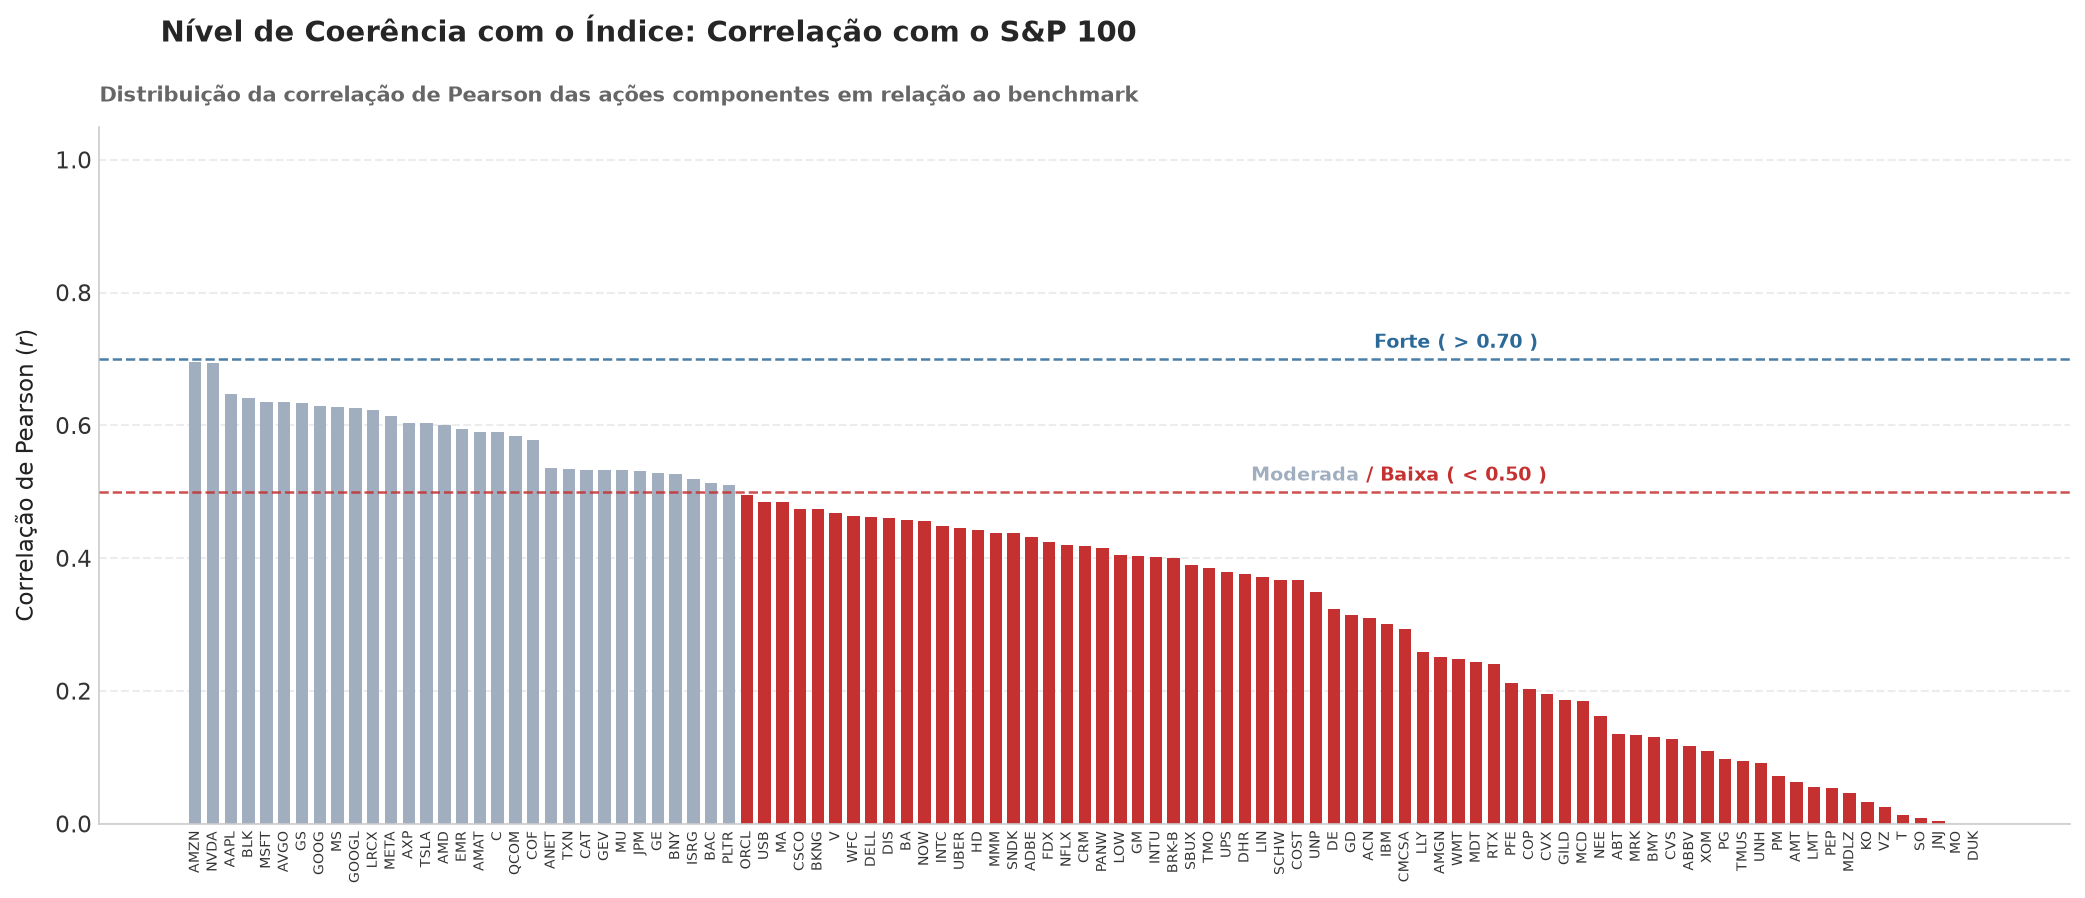


0.0% das ações têm correlação > 0.7 com o índice


In [83]:
# ══════════════════════════════════════════════════════
# Correlação de cada ação com o Índice (S&P100)
# ══════════════════════════════════════════════════════
# Alinhar os índices de data primeiro para garantir a comparação correta
datas_comuns_sp = ret_sp100.index.intersection(ret_idx_sp.index)
ret_acoes_sp_al = ret_sp100.loc[datas_comuns_sp]
ret_idx_sp_al = ret_idx_sp.loc[datas_comuns_sp]

# Calcular correlação utilizando .squeeze() para transformar o índice em Series (1D)
corr_com_idx_sp = ret_acoes_sp_al.corrwith(ret_idx_sp_al.squeeze()).sort_values(ascending=False)

print('TOP 15, Ações mais correlacionadas com o S&P100:')
print(corr_com_idx_sp.head(15).round(4))
print('\nBOTTOM 10, Ações menos correlacionadas com o S&P100:')
print(corr_com_idx_sp.tail(10).round(4))

# ==============================================================================
# GRÁFICO DE CORRELAÇÃO DAS AÇÕES COM O S&P 100 (ESTILO NYT)
# ==============================================================================
set_nyt_style()

# Garante que temos as ações e os valores ordenados para melhor leitura visual
corr_ordenada = corr_com_idx_sp.sort_values(ascending=False)
acoes = corr_ordenada.index
valores = corr_ordenada.values

# Mapeamento de Cores no Padrão do Projeto
# Alta (>0.7): Azul S&P | Moderada (0.5 a 0.7): Slate/Cinza | Baixa (<0.5): Carmesim/Alerta
cores = [
    '#0F4C81' if c > 0.7 else ('#A0AEC0' if c >= 0.5 else '#C53030') 
    for c in valores
]

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

# Criando as barras verticais
ax.bar(acoes, valores, color=cores, width=0.7, edgecolor='none')

# Linhas horizontais de referência pontilhadas
ax.axhline(0.70, color='#2B6999', linestyle='--', linewidth=1.2, alpha=0.85, zorder=3)
ax.axhline(0.50, color='#C53030', linestyle='--', linewidth=1.2, alpha=0.85, zorder=3)

# Anotações diretas nas linhas (descarta a legenda tradicional)
ax.text(len(acoes_ib) - 0.5, 0.71, 'Forte ( > 0.70 )', color='#2B6999', fontweight='bold', fontsize=9, ha='right', va='bottom')
ax.text(len(acoes_ib) - 9, 0.51, 'Moderada    ', color='#A0AEC0', fontweight='bold', fontsize=9, ha='right', va='bottom')
ax.text(len(acoes_ib) - 0, 0.51, '/ Baixa ( < 0.50 )', color='#C53030', fontweight='bold', fontsize=9, ha='right', va='bottom')


# Ajuste e formatação dos Eixos
ax.set_ylim(0, 1.05)
ax.set_ylabel('Correlação de Pearson ($r$)', fontsize=11, labelpad=8)
ax.set_xlabel('', fontsize=11)

# Rotação dos tickers das ações no eixo X
plt.xticks(rotation=90, fontsize=6.5)

# Grid sutil apenas no eixo Y
ax.grid(axis='y', color='#E5E5E5', linestyle='--', alpha=0.7)
ax.grid(axis='x', visible=False)

# Títulos no estilo editorial NYT
plt.suptitle('Nível de Coerência com o Índice: Correlação com o S&P 100', x=0.08, y=0.99, fontweight='bold', fontsize=14, ha='left')
ax.set_title(
    'Distribuição da correlação de Pearson das ações componentes em relação ao benchmark', 
    fontsize=10, color='#666666', pad=12, loc='left'
)

plt.tight_layout()
plt.savefig('correlacao_acoes_sp100.png', dpi=300, bbox_inches='tight')
plt.show()

# Calcular a porcentagem de ações com alta correlação
pct_alta_corr = (corr_com_idx_sp > 0.7).mean() * 100
print(f'\n{pct_alta_corr:.1f}% das ações têm correlação > 0.7 com o índice')

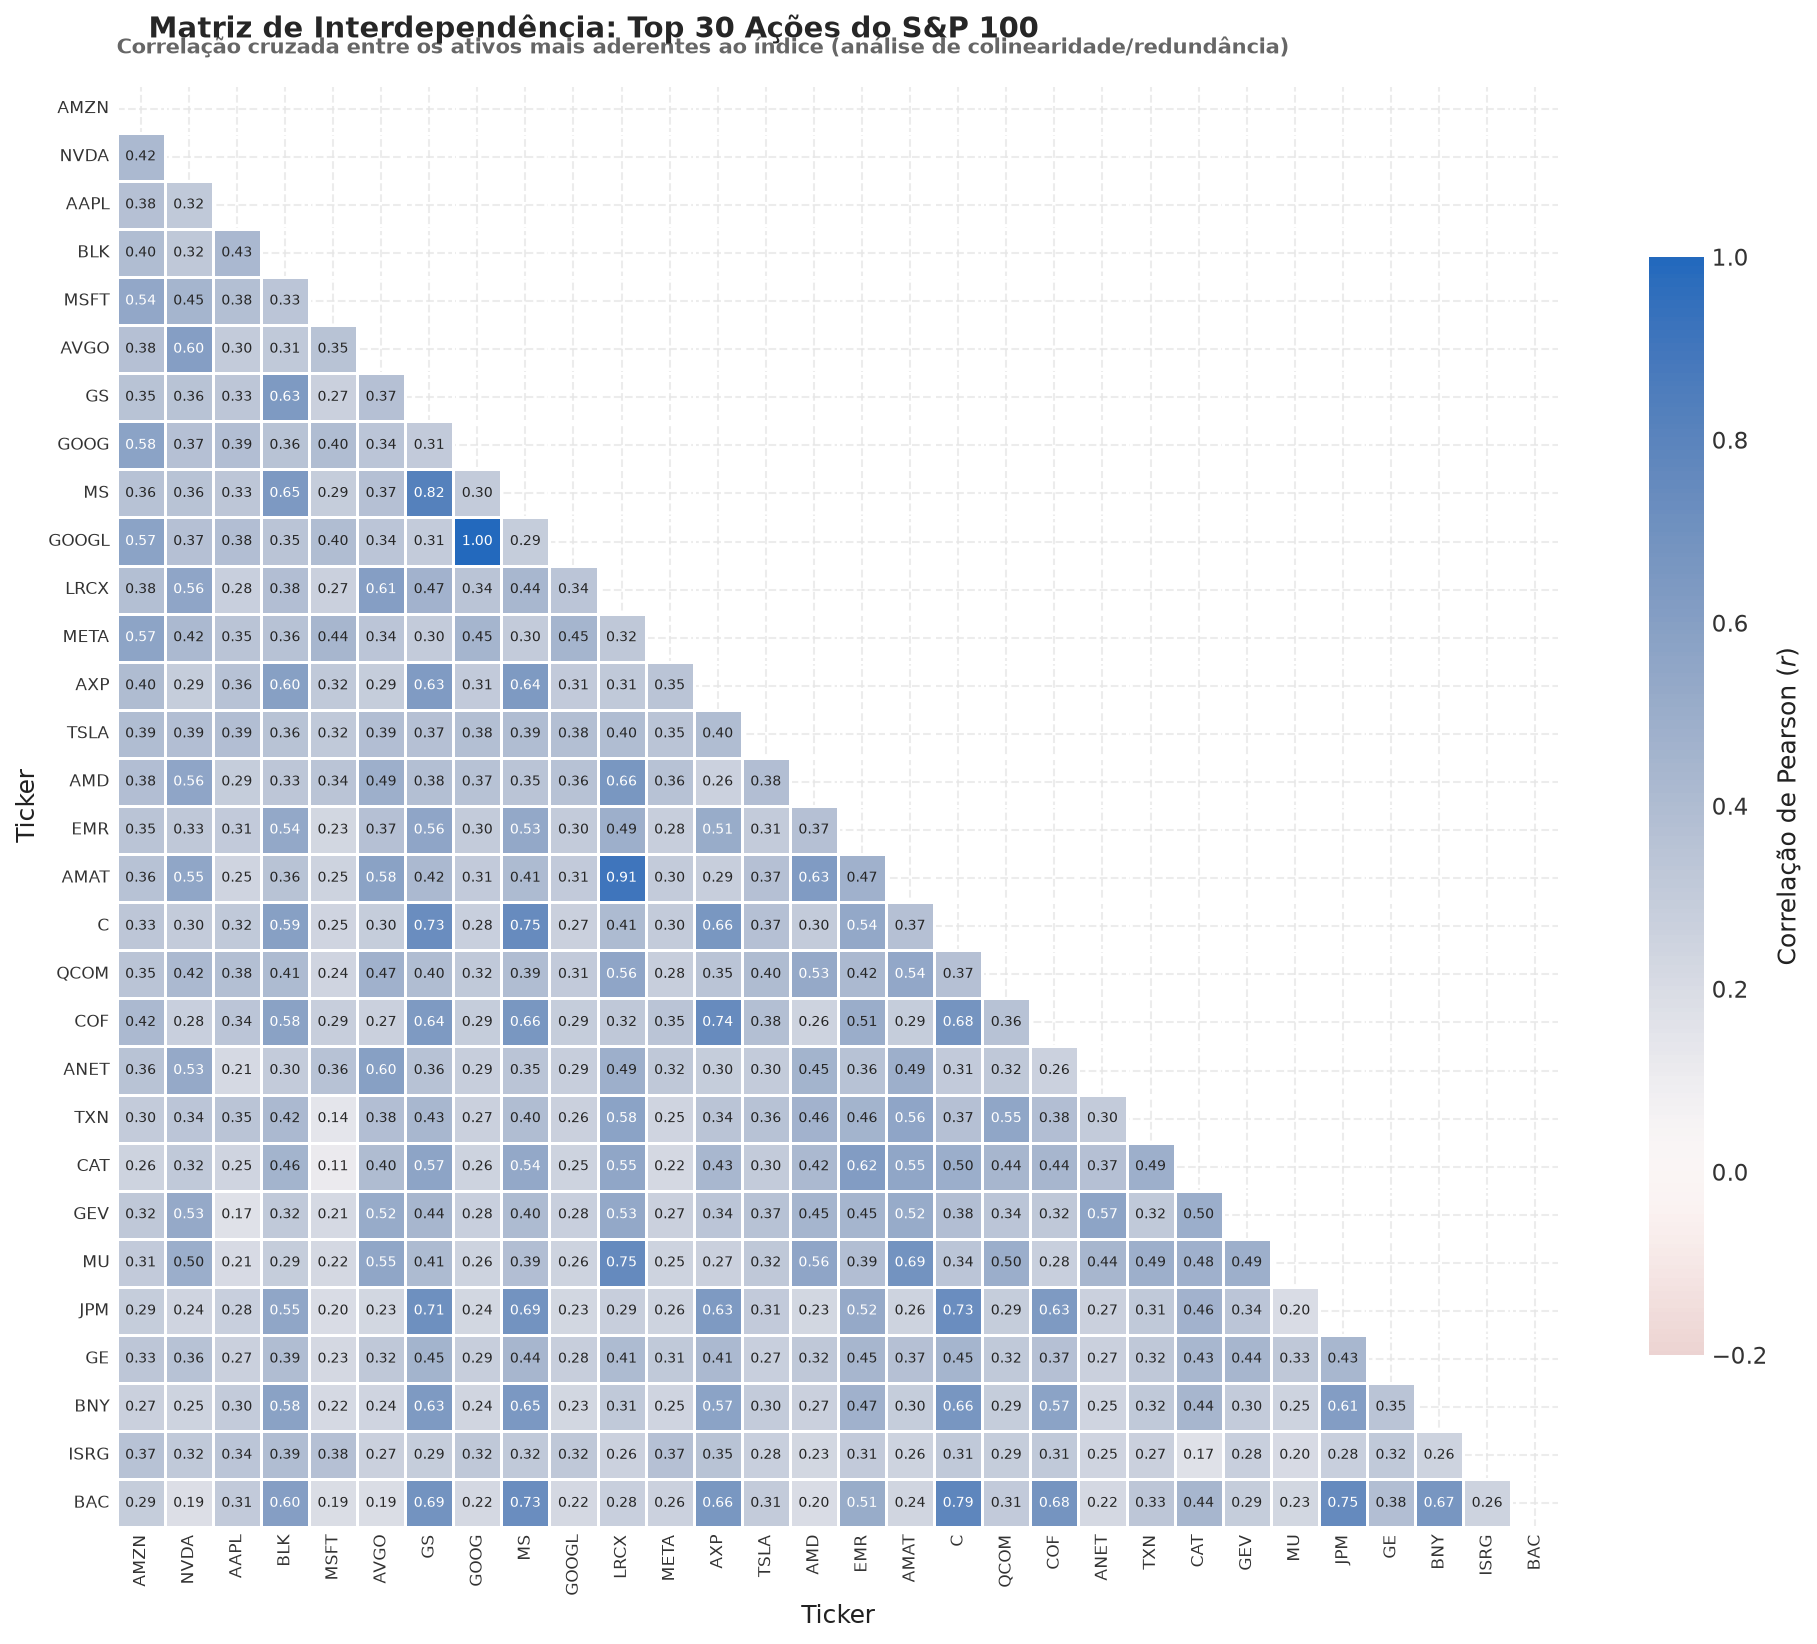

   PARES COM CORRELAÇÃO EXTREMA (> 0.90) — S&P 100
Total de pares altamente redundantes encontrados: 2

Ação 1 Ação 2  Correlação
  GOOG  GOOGL       0.997
  AMAT   LRCX       0.908


In [57]:
# ==============================================================================
# MATRIZ DE CORRELAÇÃO TOP 30 S&P 100 (ESTILO NYT)
# ==============================================================================
set_nyt_style()

# 1. Matriz de correlação geral e seleção das 30 principais ações
corr_matrix_sp = ret_sp100.corr()
top30_sp = corr_com_idx_sp.head(30).index
corr_top30_sp = ret_sp100[top30_sp].corr()

# 2. Criar figura no padrão Orientado a Objetos
fig, ax = plt.subplots(figsize=(13, 11), dpi=150)

# 3. Criar máscara para o triângulo superior (exibe apenas o triângulo inferior)
mask = np.triu(np.ones_like(corr_top30_sp, dtype=bool))

# 4. Plotar Heatmap com paleta sóbria e linhas sutis
sns.heatmap(
    corr_top30_sp,
    mask=mask,
    annot=True, 
    fmt='.2f',
    cmap='vlag_r',        # Paleta divergente sutil (Azul vs Vermelho fechado)
    center=0, 
    square=True,
    linewidths=0.5,
    linecolor='#FFFFFF',  # Linhas separadoras brancas limpas
    vmin=-0.2, vmax=1,    # Ajuste de escala focado na faixa real de correlação de ações
    cbar_kws={
        'shrink': 0.75, 
        'label': 'Correlação de Pearson ($r$)',
        'orientation': 'vertical'
    },
    annot_kws={'size': 6.5, 'weight': 'normal'},
    ax=ax
)

# 5. Ajuste nos eixos para eliminar bordas de tick
ax.tick_params(axis='both', which='both', length=0, labelsize=8)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# 6. Títulos no estilo editorial NYT
plt.suptitle(
    'Matriz de Interdependência: Top 30 Ações do S&P 100', 
    x=0.08, y=0.98, fontweight='bold', fontsize=14, ha='left'
)
ax.set_title(
    'Correlação cruzada entre os ativos mais aderentes ao índice (análise de colinearidade/redundância)', 
    fontsize=10, color='#666666', pad=15, loc='left'
)

plt.tight_layout()
plt.savefig('matriz_correlacao_sp100.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# BUSCA DE PARES DE ALTA CORRELAÇÃO (REDUNDÂNCIA PARA O SOLVER)
# ==============================================================================
pares_alta_corr = []
for i in range(len(corr_matrix_sp.columns)):
    for j in range(i + 1, len(corr_matrix_sp.columns)):
        r = corr_matrix_sp.iloc[i, j]
        if r > 0.90:
            pares_alta_corr.append({
                'Ação 1': corr_matrix_sp.columns[i],
                'Ação 2': corr_matrix_sp.columns[j],
                'Correlação': round(r, 3)
            })

df_pares = pd.DataFrame(pares_alta_corr).sort_values('Correlação', ascending=False)

print("=" * 60)
print(f"   PARES COM CORRELAÇÃO EXTREMA (> 0.90) — S&P 100")
print("=" * 60)
print(f"Total de pares altamente redundantes encontrados: {len(df_pares)}\n")
if len(df_pares) > 0:
    print(df_pares.head(20).to_string(index=False))
print("=" * 60)

TOP 15, Ações mais correlacionadas com o IBOVESPA:
Ticker
ITSA4.SA     0.8089
ITUB4.SA     0.7693
B3SA3.SA     0.7567
BPAC11.SA    0.7454
ALOS3.SA     0.7336
BBDC3.SA     0.7144
IGTI11.SA    0.7125
MULT3.SA     0.6988
CSAN3.SA     0.6851
BBDC4.SA     0.6834
MOTV3.SA     0.6782
ENGI11.SA    0.6743
EQTL3.SA     0.6602
CYRE3.SA     0.6531
RENT3.SA     0.6505
dtype: float64

BOTTOM 10, Ações menos correlacionadas com o IBOVESPA:
Ticker
POMO4.SA    0.3966
WEGE3.SA    0.3598
CSMG3.SA    0.3535
BEEF3.SA    0.3464
BRAV3.SA    0.3439
MBRF3.SA    0.3214
PRIO3.SA    0.3044
EMBJ3.SA    0.2433
SUZB3.SA    0.2210
NATU3.SA    0.1792
dtype: float64


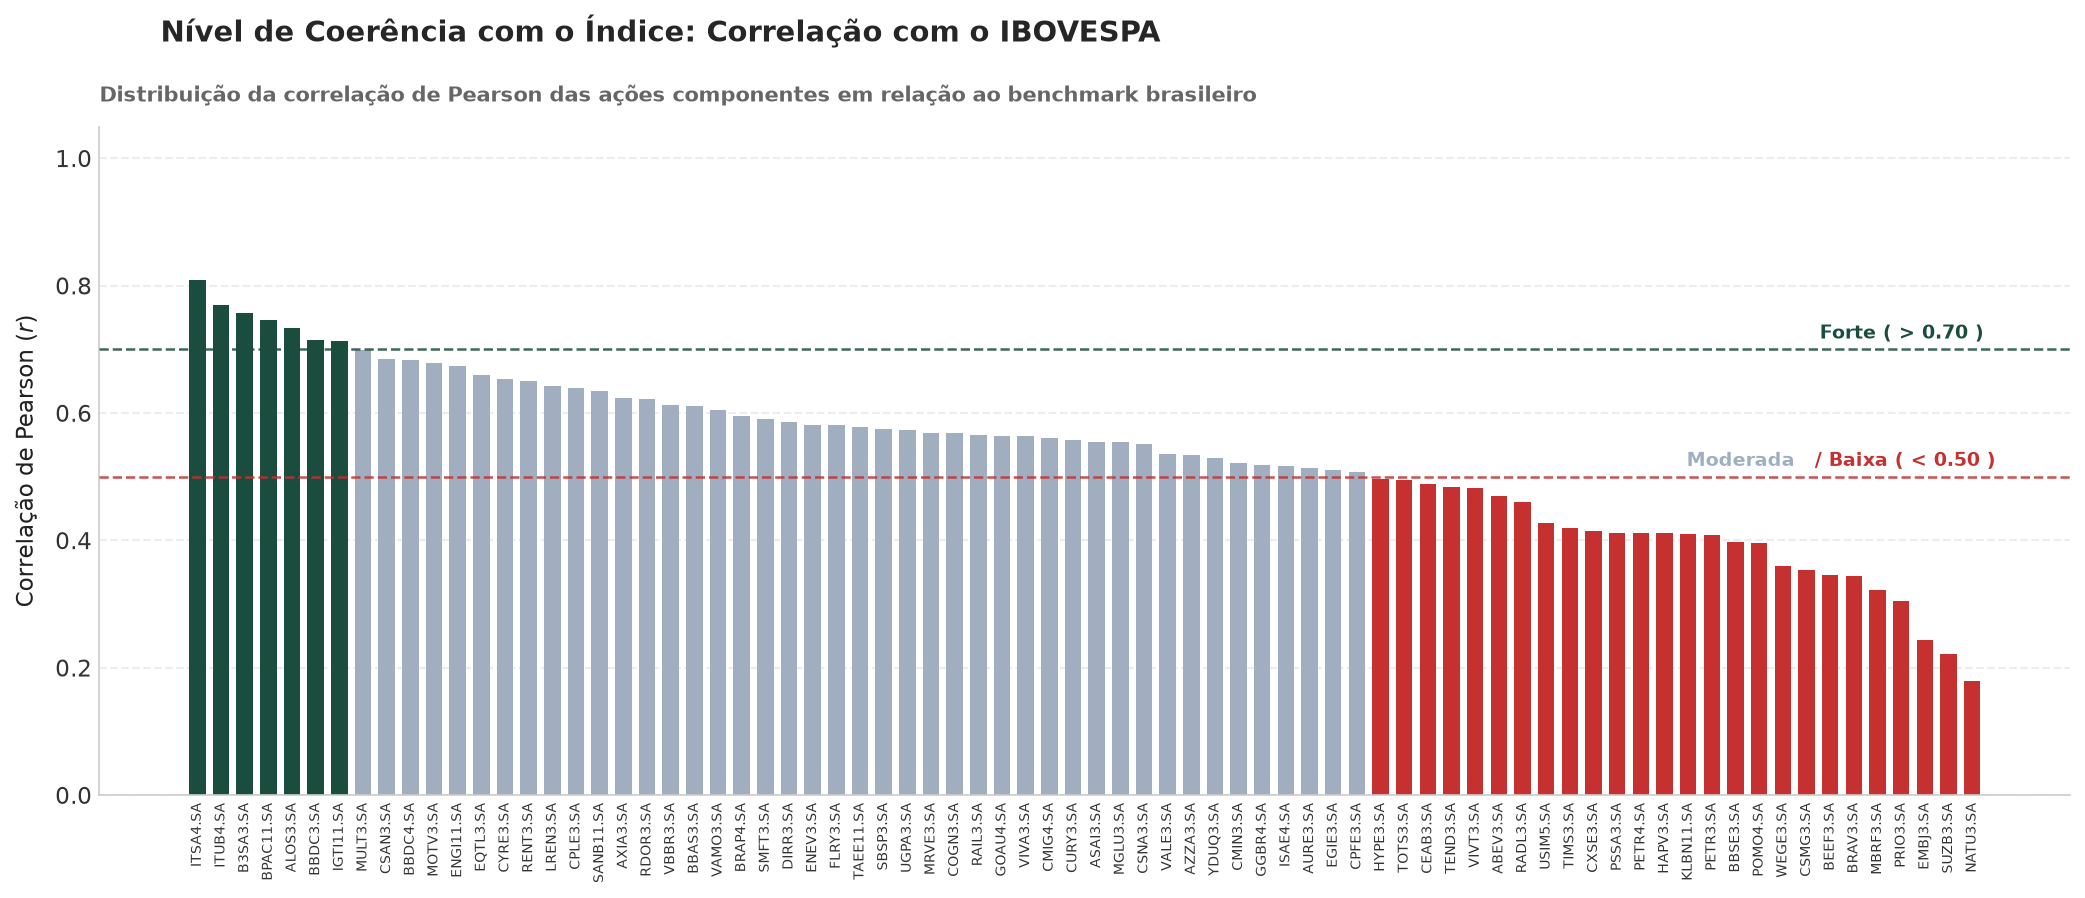


9.2% das ações têm correlação > 0.7 com o índice


In [86]:
# ══════════════════════════════════════════════════════
# Correlação de cada ação com o Índice (IBOVESPA)
# ══════════════════════════════════════════════════════
# Alinhar os índices de data primeiro para garantir a comparação correta
datas_comuns_ib = ret_ibov.index.intersection(ret_idx_ib.index)
ret_acoes_ib_al = ret_ibov.loc[datas_comuns_ib]
ret_idx_ib_al = ret_idx_ib.loc[datas_comuns_ib]

# Calcular correlação utilizando .squeeze() para transformar o índice em Series (1D)
corr_com_idx_ib = ret_acoes_ib_al.corrwith(ret_idx_ib_al.squeeze()).sort_values(ascending=False)

print('TOP 15, Ações mais correlacionadas com o IBOVESPA:')
print(corr_com_idx_ib.head(15).round(4))
print('\nBOTTOM 10, Ações menos correlacionadas com o IBOVESPA:')
print(corr_com_idx_ib.tail(10).round(4))

# ==============================================================================
# GRÁFICO DE CORRELAÇÃO DAS AÇÕES COM O IBOVESPA (ESTILO NYT)
# ==============================================================================
set_nyt_style()

# 1. Ordenação decrescente dos dados para melhor leitura visual
corr_ordenada_ib = corr_com_idx_ib.sort_values(ascending=False)
acoes_ib = corr_ordenada_ib.index
valores_ib = corr_ordenada_ib.values

# 2. Mapeamento de Cores no Padrão do Projeto
# Alta (>0.7): Verde IBOV | Moderada (0.5 a 0.7): Slate/Cinza | Baixa (<0.5): Carmesim/Alerta
cores_ib = [
    '#1B4D3E' if c > 0.7 else ('#A0AEC0' if c >= 0.5 else '#C53030') 
    for c in valores_ib
]

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

# 3. Criando as barras verticais
ax.bar(acoes_ib, valores_ib, color=cores_ib, width=0.7, edgecolor='none')

# 4. Linhas horizontais de referência pontilhadas
ax.axhline(0.70, color='#1B4D3E', linestyle='--', linewidth=1.2, alpha=0.85, zorder=3)
ax.axhline(0.50, color='#C53030', linestyle='--', linewidth=1.2, alpha=0.85, zorder=3)

# 5. Anotações diretas nas linhas (sem poluição de legenda)
ax.text(len(acoes_ib) - 0.5, 0.71, 'Forte ( > 0.70 )', color='#1B4D3E', fontweight='bold', fontsize=9, ha='right', va='bottom')
ax.text(len(acoes_ib) - 8.5, 0.51, 'Moderada', color='#A0AEC0', fontweight='bold', fontsize=9, ha='right', va='bottom')
ax.text(len(acoes_ib) - 0, 0.51, '/ Baixa ( < 0.50 )', color='#C53030', fontweight='bold', fontsize=9, ha='right', va='bottom')


# 6. Ajuste e formatação dos Eixos
ax.set_ylim(0, 1.05)
ax.set_ylabel('Correlação de Pearson ($r$)', fontsize=11, labelpad=8)
ax.set_xlabel('', fontsize=11)

# Rotação dos tickers das ações no eixo X
plt.xticks(rotation=90, fontsize=6.5)

# Grid sutil apenas no eixo Y
ax.grid(axis='y', color='#E5E5E5', linestyle='--', alpha=0.7)
ax.grid(axis='x', visible=False)

# 7. Títulos no estilo editorial NYT
plt.suptitle('Nível de Coerência com o Índice: Correlação com o IBOVESPA', x=0.08, y=0.99, fontweight='bold', fontsize=14, ha='left')
ax.set_title(
    'Distribuição da correlação de Pearson das ações componentes em relação ao benchmark brasileiro', 
    fontsize=10, color='#666666', pad=12, loc='left'
)

plt.tight_layout()
plt.savefig('correlacao_acoes_ibovespa.png', dpi=300, bbox_inches='tight')
plt.show()

# Calcular a porcentagem de ações com alta correlação
pct_alta_corr_ib = (corr_com_idx_ib > 0.7).mean() * 100
print(f'\n{pct_alta_corr_ib:.1f}% das ações têm correlação > 0.7 com o índice')

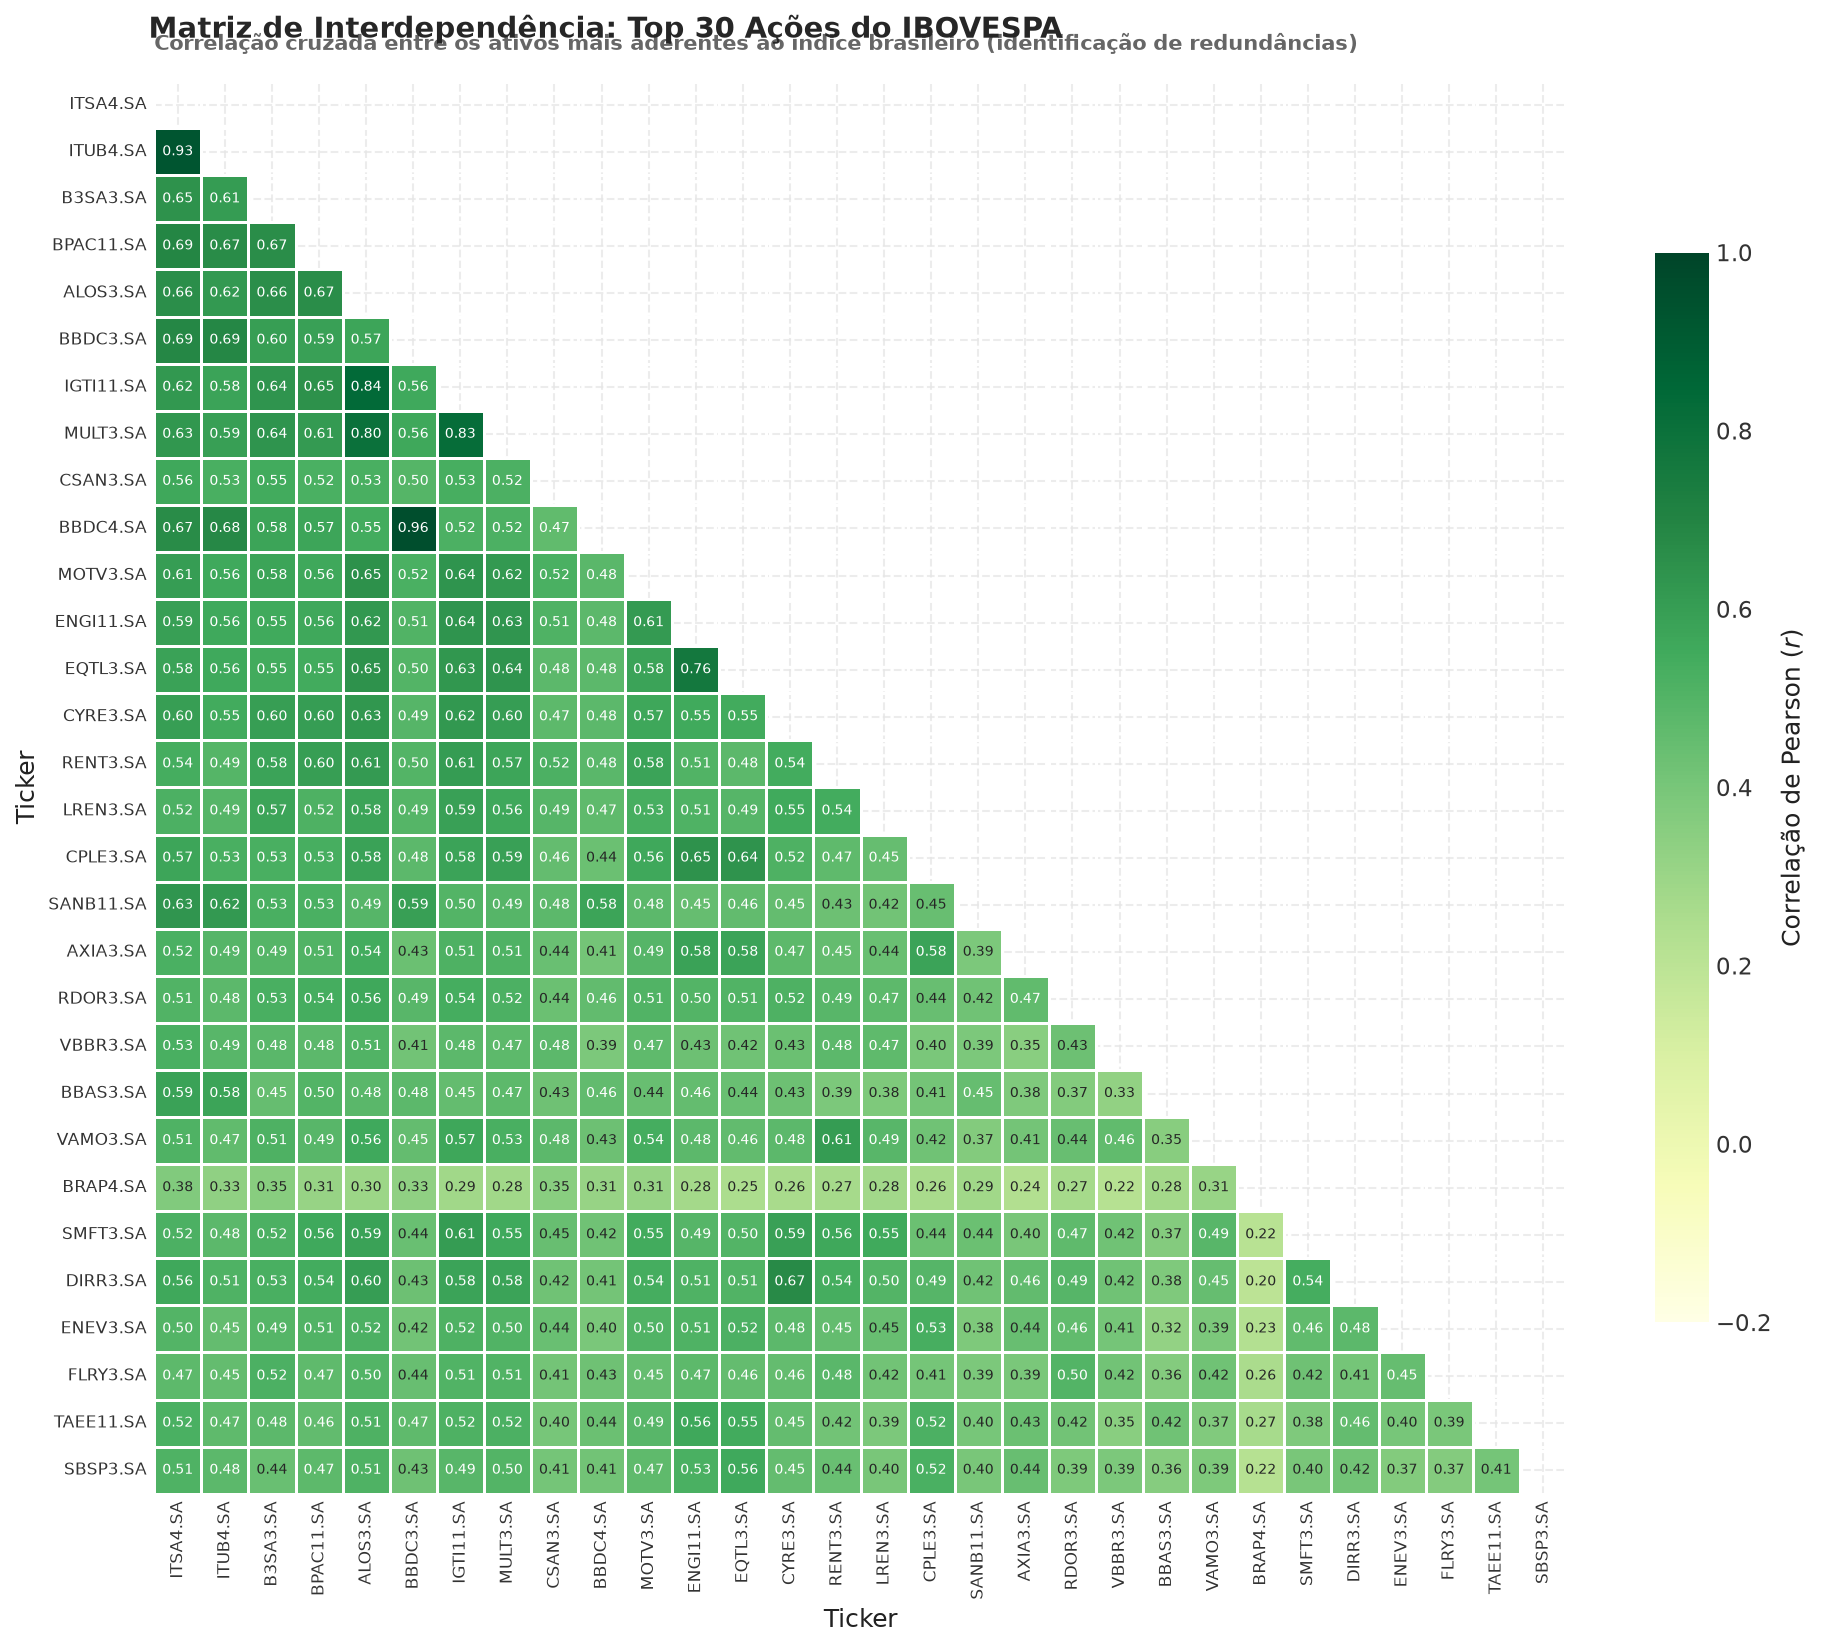

   PARES COM CORRELAÇÃO EXTREMA (> 0.90) — IBOVESPA
Total de pares altamente redundantes encontrados: 5

  Ação 1   Ação 2  Correlação
PETR3.SA PETR4.SA       0.966
BBDC3.SA BBDC4.SA       0.961
GGBR4.SA GOAU4.SA       0.953
ITSA4.SA ITUB4.SA       0.926
BRAP4.SA VALE3.SA       0.903


In [ ]:
# ==============================================================================
# MATRIZ DE CORRELAÇÃO TOP 30 IBOVESPA (ESTILO NYT)
# ==============================================================================
set_nyt_style()

# 1. Matriz de correlação geral e seleção das 30 principais ações
corr_matrix_ib = ret_ibov.corr()
top30_ib = corr_com_idx_ib.head(30).index
corr_top30_ib = ret_ibov[top30_ib].corr()

# 2. Criar figura no padrão Orientado a Objetos
fig, ax = plt.subplots(figsize=(13, 11), dpi=150)

# 3. Criar máscara para o triângulo superior (exibe apenas o triângulo inferior)
mask_ib = np.triu(np.ones_like(corr_top30_ib, dtype=bool))

# 4. Plotar Heatmap no padrão verde/editorial do IBOVESPA
sns.heatmap(
    corr_top30_ib,
    mask=mask_ib,
    annot=True, 
    fmt='.2f',
    cmap='YlGn',           # Paleta verde sutil e elegante para a identidade do IBOV
    center=0.4, 
    square=True,
    linewidths=0.5,
    linecolor='#FFFFFF',   # Linhas separadoras brancas limpas
    vmin=-0.2, vmax=1,     # Escala ajustada para focar na variação real de correlações de ações
    cbar_kws={
        'shrink': 0.75, 
        'label': 'Correlação de Pearson ($r$)',
        'orientation': 'vertical'
    },
    annot_kws={'size': 6.5, 'weight': 'normal'},
    ax=ax
)

# 5. Ajuste nos eixos para eliminar poluição de bordas
ax.tick_params(axis='both', which='both', length=0, labelsize=8)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# 6. Títulos no estilo editorial NYT
plt.suptitle(
    'Matriz de Interdependência: Top 30 Ações do IBOVESPA', 
    x=0.08, y=0.98, fontweight='bold', fontsize=14, ha='left'
)
ax.set_title(
    'Correlação cruzada entre os ativos mais aderentes ao índice brasileiro (identificação de redundâncias)', 
    fontsize=10, color='#666666', pad=15, loc='left'
)

plt.tight_layout()
plt.savefig('matriz_correlacao_ibovespa.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# BUSCA DE PARES DE ALTA CORRELAÇÃO (REDUNDÂNCIA PARA O SOLVER)
# ==============================================================================
pares_alta_corr_ib = []
for i in range(len(corr_matrix_ib.columns)):
    for j in range(i + 1, len(corr_matrix_ib.columns)):
        r = corr_matrix_ib.iloc[i, j]
        if r > 0.90:
            pares_alta_corr_ib.append({
                'Ação 1': corr_matrix_ib.columns[i],
                'Ação 2': corr_matrix_ib.columns[j],
                'Correlação': round(r, 3)
            })

df_pares_ib = pd.DataFrame(pares_alta_corr_ib).sort_values('Correlação', ascending=False)

print("=" * 60)
print("   PARES COM CORRELAÇÃO EXTREMA (> 0.90) — IBOVESPA")
print("=" * 60)
print(f"Total de pares altamente redundantes encontrados: {len(df_pares_ib)}\n")
if len(df_pares_ib) > 0:
    print(df_pares_ib.head(20).to_string(index=False))
print("=" * 60)

In [87]:
# Cálculo do Beta em relação ao S&P 100
def calcular_metricas_replicacao(ret_acoes, ret_indice):
    col_idx = ret_indice.columns[0]
    var_indice = ret_indice[col_idx].var()
    
    metricas = []
    
    for col in ret_acoes.columns:
        r = ret_acoes[col].corr(ret_indice[col_idx])
        cov = ret_acoes[col].cov(ret_indice[col_idx])
        beta = cov / var_indice
        vol_acao = ret_acoes[col].std() * np.sqrt(252) # Volatilidade anualizada
        
        # Tracking error individual em relação ao índice
        te_individual = (ret_acoes[col] - ret_indice[col_idx]).std() * np.sqrt(252)
        
        metricas.append({
            'Ativo': col,
            'Pearson r': r,
            'Beta (β)': beta,
            'Volatilidade Anual': vol_acao,
            'Tracking Error Ind.': te_individual
        })
        
    df_metricas = pd.DataFrame(metricas).sort_values(by='Pearson r', ascending=False)
    return df_metricas

# Execução no S&P 100
df_analise_sp100 = calcular_metricas_replicacao(ret_sp100, ret_idx_sp)
df_analise_ibov = calcular_metricas_replicacao(ret_ibov, ret_idx_ib)

# Comparar com as Top 5 mais correlacionadas
print(df_analise_sp100.head(10).to_string(index=False, formatters={
    'Pearson r': '{:.4f}'.format,
    'Beta (β)': '{:.2f}'.format,
    'Volatilidade Anual': '{:.2%}'.format,
    'Tracking Error Ind.': '{:.2%}'.format
}))

print(df_analise_ibov.head(10).to_string(index=False, formatters={
    'Pearson r': '{:.4f}'.format,
    'Beta (β)': '{:.2f}'.format,
    'Volatilidade Anual': '{:.2%}'.format,
    'Tracking Error Ind.': '{:.2%}'.format
}))

Ativo Pearson r Beta (β) Volatilidade Anual Tracking Error Ind.
 AMZN    0.6950     1.44             32.35%              24.25%
 NVDA    0.6935     2.11             47.51%              38.35%
 AAPL    0.6466     1.06             25.71%              19.63%
  BLK    0.6409     0.99             24.19%              18.57%
 MSFT    0.6358     1.06             26.13%              20.20%
 AVGO    0.6357     1.89             46.49%              38.49%
   GS    0.6340     1.16             28.64%              22.29%
 GOOG    0.6298     1.22             30.36%              23.83%
   MS    0.6272     1.13             28.09%              21.97%
GOOGL    0.6256     1.22             30.60%              24.13%
    Ativo Pearson r Beta (β) Volatilidade Anual Tracking Error Ind.
 ITSA4.SA    0.8089     1.09             21.30%              12.61%
 ITUB4.SA    0.7693     1.07             21.93%              14.06%
 B3SA3.SA    0.7567     1.59             33.07%              23.51%
BPAC11.SA    0.7454     

Total de ações mapeadas no S&P 100: 101 de 101


C:\Users\nbago\AppData\Local\Temp\ipykernel_27512\1582480510.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


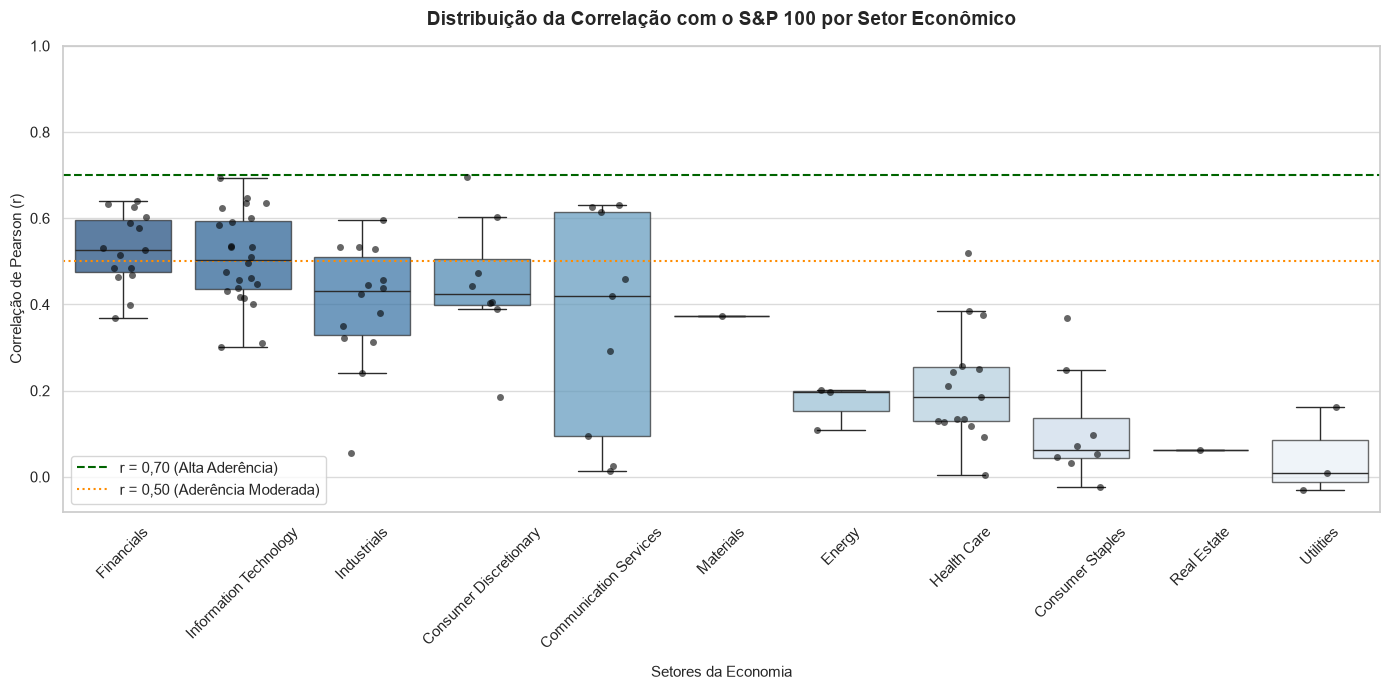

      RESUMO DE ADERÊNCIA SETORIAL AO S&P 100
                Sector  Qtd_Ações Mediana  Média Desvio_Padrão
            Financials         15  0.5263 0.5275        0.0844
Information Technology         24  0.5025 0.5072        0.1049
           Industrials         14  0.4312 0.4011        0.1407
Consumer Discretionary          8  0.4233 0.4495        0.1522
Communication Services          9  0.4202 0.3528        0.2570
             Materials          1  0.3720 0.3720           NaN
                Energy          3  0.1960 0.1692        0.0520
           Health Care         15  0.1863 0.2114        0.1334
      Consumer Staples          8  0.0631 0.1119        0.1298
           Real Estate          1  0.0627 0.0627           NaN
             Utilities          3  0.0088 0.0469        0.1024

Total de ações mapeadas no IBOVESPA: 76 de 76


C:\Users\nbago\AppData\Local\Temp\ipykernel_27512\1582480510.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


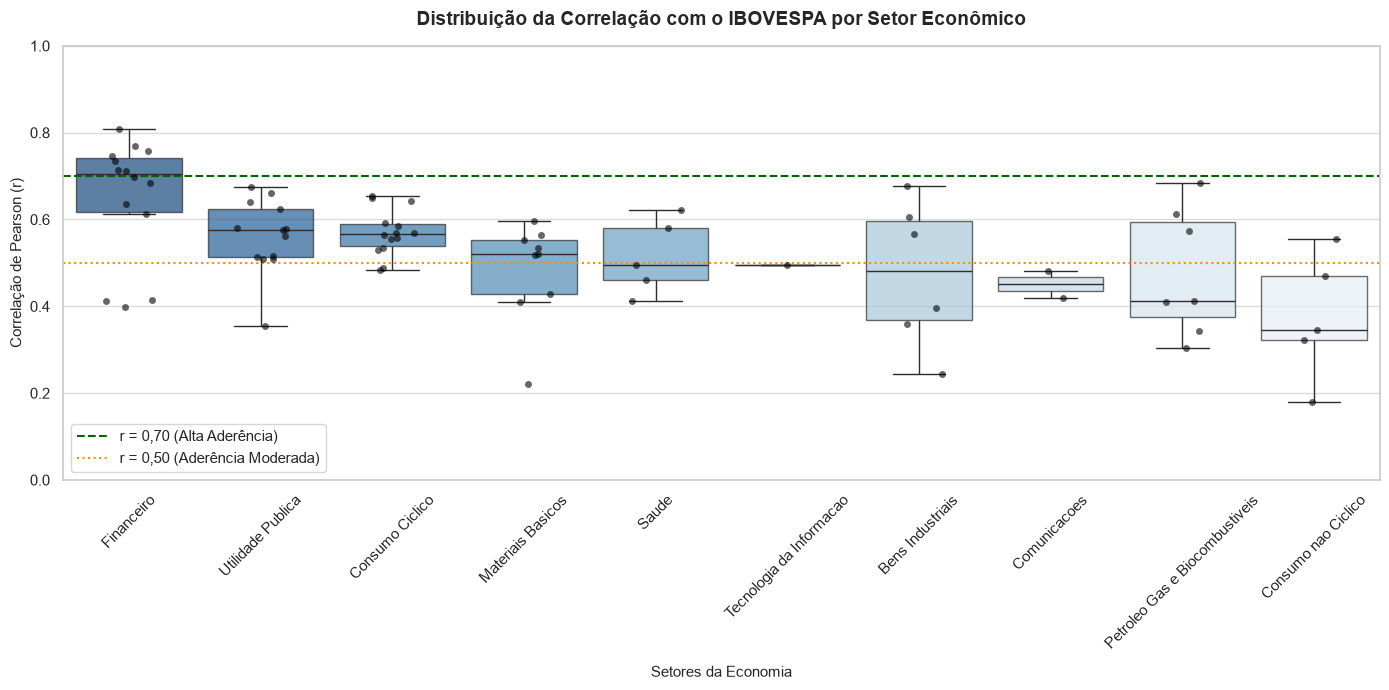

      RESUMO DE ADERÊNCIA SETORIAL AO IBOVESPA
                         Setor  Qtd_Ações Mediana  Média Desvio_Padrão
                    Financeiro         14  0.7056 0.6497        0.1401
             Utilidade Publica         13  0.5756 0.5613        0.0848
               Consumo Ciclico         14  0.5664 0.5696        0.0533
             Materiais Basicos          9  0.5210 0.4829        0.1155
                         Saude          5  0.4960 0.5142        0.0866
      Tecnologia da Informacao          1  0.4944 0.4944           NaN
              Bens Industriais          6  0.4814 0.4749        0.1672
                  Comunicacoes          2  0.4506 0.4506        0.0447
Petroleo Gas e Biocombustiveis          7  0.4116 0.4771        0.1457
           Consumo nao Ciclico          5  0.3464 0.3743        0.1444



In [94]:
# Configuração estética do Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

def plotar_boxplot_correlacao_setorial(ret_acoes, ret_indice, path_csv_setores, col_ticker, col_setor, nome_indice):
    """
    Carrega o mapeamento setorial, calcula a correlação de Pearson por ativo,
    agrupa por setor e plota o Boxplot ordenado pela mediana.
    """
    col_idx = ret_indice.columns[0]
    
    # 1. Carregar mapeamento setorial do CSV
    df_setores = pd.read_csv(path_csv_setores)
    
    # Padronizar nomes de tickers (ex: remover espaços ou converter formatos se necessário)
    df_setores[col_ticker] = df_setores[col_ticker].astype(str).str.strip()
    
    # 2. Calcular correlação de Pearson de cada ação com o benchmark
    correlacoes = ret_acoes.apply(lambda col: col.corr(ret_indice[col_idx]))
    df_corr = pd.DataFrame({
        col_ticker: correlacoes.index,
        'Pearson_R': correlacoes.values
    })
    
    # Garantir compatibilidade de tickers entre o retorno e o arquivo de setores
    # Exemplo: Se os tickers do ret_acoes tiverem '.SA' (IBOV) ou '-B' (S&P), ajustamos no merge
    df_merged = pd.merge(df_corr, df_setores, on=col_ticker, how='inner')
    
    if df_merged.empty:
        # Tentativa de ajuste caso os tickers do CSV estejam sem sufixo .SA
        df_corr_temp = df_corr.copy()
        df_corr_temp[col_ticker] = df_corr_temp[col_ticker].str.replace('.SA', '', regex=False).str.replace('-', '.', regex=False)
        df_merged = pd.merge(df_corr_temp, df_setores, on=col_ticker, how='inner')
    
    print(f"Total de ações mapeadas no {nome_indice}: {len(df_merged)} de {ret_acoes.shape[1]}")
    
    # 3. Ordenar setores pela MEDIANA da correlação (do maior para o menor)
    ordem_setores = (
        df_merged.groupby(col_setor)['Pearson_R']
        .median()
        .sort_values(ascending=False)
        .index
    )
    
    # 4. Criar o Boxplot com sobreposição de pontos individuais (Swarmplot/Stripplot)
    fig, ax = plt.subplots(figsize=(14, 7))
    
    sns.boxplot(
        data=df_merged,
        x=col_setor,
        y='Pearson_R',
        order=ordem_setores,
        palette='Blues_r',
        ax=ax,
        fliersize=0,      # Oculta outliers do boxplot para não duplicar com o stripplot
        boxprops=dict(alpha=0.7)
    )
    
    # Sobreposição dos pontos das ações individuais para dar visibilidade ao N por setor
    sns.stripplot(
        data=df_merged,
        x=col_setor,
        y='Pearson_R',
        order=ordem_setores,
        color='black',
        alpha=0.6,
        jitter=0.2,
        size=5,
        ax=ax
    )
    
    # Linhas de referência de aderência
    ax.axhline(y=0.70, color='darkgreen', linestyle='--', linewidth=1.5, label='r = 0,70 (Alta Aderência)')
    ax.axhline(y=0.50, color='darkorange', linestyle=':', linewidth=1.5, label='r = 0,50 (Aderência Moderada)')
    
    # Títulos e formatação
    ax.set_title(f'Distribuição da Correlação com o {nome_indice} por Setor Econômico', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Setores da Economia', fontsize=11, labelpad=10)
    ax.set_ylabel('Correlação de Pearson (r)', fontsize=11)
    ax.set_ylim(min(0, df_merged['Pearson_R'].min() - 0.05), 1.0)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='lower left', frameon=True, facecolor='white')
    
    plt.tight_layout()
    plt.show()
    
    # 5. Tabela Resumo com Estatísticas Setoriais
    resumo_setorial = df_merged.groupby(col_setor)['Pearson_R'].agg(
        Qtd_Ações='count',
        Mediana='median',
        Média='mean',
        Desvio_Padrão='std'
    ).loc[ordem_setores].reset_index()
    
    print("=" * 65)
    print(f"      RESUMO DE ADERÊNCIA SETORIAL AO {nome_indice}")
    print("=" * 65)
    print(resumo_setorial.to_string(index=False, formatters={
        'Mediana': '{:.4f}'.format,
        'Média': '{:.4f}'.format,
        'Desvio_Padrão': '{:.4f}'.format
    }))
    print("=" * 65 + "\n")
    
    return df_merged, resumo_setorial

# ---------------------------------------------------------
# EXECUÇÃO PARA S&P 100 E IBOVESPA
# ---------------------------------------------------------
df_setores_sp100, resumo_sp100 = plotar_boxplot_correlacao_setorial(
    ret_acoes=ret_sp100,
    ret_indice=ret_idx_sp,
    path_csv_setores='SP100_wikipedia_21set2026.csv',
    col_ticker='Symbol',       # Ajuste se no seu CSV for 'Symbol'
    col_setor='Sector',         # Ajuste se no seu CSV for 'GICS Sector'
    nome_indice='S&P 100'
)

df_setores_ibov, resumo_ibov = plotar_boxplot_correlacao_setorial(
    ret_acoes=ret_ibov,
    ret_indice=ret_idx_ib,
    path_csv_setores='IBOVESPA_B3_24set2026.csv',
    col_ticker='Codigo',       # Ajuste se no seu CSV for 'Código'
    col_setor='Setor',          # Ajuste se no seu CSV for 'Setor Econômico'
    nome_indice='IBOVESPA'
)